<div style="border:solid green 2px; padding: 20px">
    
<b>Сергей, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Это Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Поведенческий скоринг клиентов банка «Ва-банк»: прогноз просрочки 90+ дней

**Заказчик:** розничный банк «Ва-банк», сегмент потребительского кредитования.

**Проблема.** Классический кредитный скоринг оценивает заёмщика один раз - в момент выдачи кредита.
Он не видит клиентов, которые уже получили деньги и начали выходить на просрочку. Просрочка свыше 90 дней
заставляет банк формировать резервы под 100% проблемного долга, что замораживает капитал,
снижает ликвидность и создаёт регуляторные риски.

**Цель проекта.** Построить модель поведенческого скоринга, которая для клиента в конкретный месяц
предсказывает, возникнет ли у него просрочка длительностью от 90 дней в ближайшие 12 месяцев.
Точный прогноз позволяет заранее управлять резервами и увеличить объём средств в обороте на 5-10%.

**Объект наблюдения:** пара «клиент - месяц скоринга» (`ID`, `score_date`).

**Исходные данные - 8 таблиц:**

| Таблица | Файл | Содержание |
|---|---|---|
| Просрочки | `ds_15_loan_payment_credit.csv` | дата начала периода просрочки и её длительность в днях |
| Транзакции | `ds_15_transactions.csv` | помесячные траты клиента по 7 MCC-кодам и прочим категориям |
| Клиенты | `ds_15_client_description.csv` | возраст, семейное положение, иждивенцы, дата регистрации |
| Кредиты | `ds_15_credit_description.csv` | доход и сумма выданного кредита |
| Ипотека | `ds_15_mortgage_presence.csv` | факт и дата оформления ипотеки |
| Кредитный рейтинг | `ds_15_credit_rating.csv` | помесячный рейтинг из внешнего источника |
| Макроэкономика | `ds_15_macro_data.csv` | учётная ставка, безработица, инфляция по месяцам |
| Сетка скоринга | `ds_15_cohort_grid.csv` | пары «клиент - дата скоринга», для которых нужен прогноз |

**Ключевые требования к качеству:** approval rate не менее 65%, default rate не более 2%,
missed defaults rate не более 4%.

## Постановка задачи в терминах машинного обучения

**Тип задачи:** бинарная классификация с сильным дисбалансом классов и временной структурой данных.

**Целевая переменная** `target` для строки (`ID`, `score_date`):

* `1` - первая просрочка клиента длительностью от 90 дней начинается в интервале
  `[score_date, score_date + 12 месяцев)`;
* `0` - в этом горизонте такой просрочки нет.

**Что будем делать:**

1. **Признаки.** Собираем витрину из 8 источников. Жёсткое правило - в строку с датой `score_date`
   попадают только те данные, которые физически доступны банку **до** этой даты. Помесячные
   источники (транзакции, рейтинг, макро) берём со сдвигом не менее чем на 1 месяц назад,
   потому что месячная агрегация за месяц `t` становится известна только после его окончания.
2. **Новые признаки.** Долговая нагрузка, отношение трат к доходу, тренд и волатильность трат,
   динамика кредитного рейтинга, стаж отношений с банком, структура трат по MCC.
3. **Разделение данных.** Три выборки строго по времени: обучающая, калибровочная и тестовая
   (последние 12 месяцев). Внутри обучающей выборки кросс-валидация на 3 фолдах с
   `GroupTimeSeriesSplit()`, где группой выступает месяц скоринга: окна валидации годовые и не
   пересекаются, а фолд валидации всегда лежит в будущем относительно фолда обучения.
4. **Модели.** Базовые: логистическая регрессия и случайный лес, каждый в двух вариантах -
   без балансировки и с балансировкой классов. Итоговое решение - `RandomForestClassifier`
   с подобранной стратегией балансировки и гиперпараметрами (Optuna, метрика
   missed defaults rate).
5. **Кодирование.** Категориальный признак кодируем `OneHotEncoder` внутри `Pipeline`,
   числовые масштабируем `StandardScaler` (нужно логистической регрессии). Препроцессор обучается
   только на обучающих фолдах - это защита от утечки.
6. **Калибровка.** Изотоническая калибровка вероятностей случайного леса на отдельной
   калибровочной выборке, контроль по коэффициенту Бриера и графику калибровки.
7. **Порог.** Подбираем порог вероятности так, чтобы approval rate был максимальным при
   default rate не выше 2% и missed defaults rate не выше 4%.

**Метрики:**

* технические - ROC-AUC, accuracy, precision, recall, F1;
* бизнесовые - approval rate = `(TN + FN) / N`, default rate = `FN / (TN + FN)`,
  missed defaults rate = `FN / (FN + TP)`.

Здесь «одобрение» = предсказанный класс 0 (клиент считается надёжным).

**Итоговая мысль.** Задача сводится к ранжированию клиентов по вероятности дефолта и к выбору
порога отсечения, который даёт максимальный объём одобрений при заданных ограничениях на риск.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Задача корректно определена как бинарная классификация

## Загрузка библиотек

Проект использует три библиотеки, которых нет в базовом окружении: `optuna` (подбор
гиперпараметров), `imbalanced-learn` (методы балансировки классов) и `mlxtend` (реализация
`GroupTimeSeriesSplit`). Ячейка ниже доустанавливает только их и печатает версии; повторный запуск
ничего не меняет. Импорт этих трёх библиотек стоит **после** установки: на чистом ядре их
ещё нет, и импорт в начале ячейки упал бы с `ModuleNotFoundError` раньше, чем `pip` успел бы
отработать.

Версии подобраны под окружение платформы (Python 3.9, scikit-learn 0.24):

* `imbalanced-learn==0.8.1` - последняя ветка, совместимая с scikit-learn 0.24;
* `mlxtend==0.23.4` ставится с `--no-deps`, потому что из него нужен только класс
  `GroupTimeSeriesSplit` (чистый Python), а его метаданные потребовали бы обновления
  scikit-learn - трогать основной стек платформы мы не хотим.

In [1]:
import importlib
import importlib.util
import site
import subprocess
import sys

import matplotlib
import numpy
import pandas
import seaborn
import sklearn

# версия imbalanced-learn выбирается по версии scikit-learn: ветка 0.8 -
# последняя, работающая
# с 0.24, но она не переживает scikit-learn 1.3, где убрали
# if_delegate_has_method
SKLEARN_VERSION = tuple(
    int(part) for part in sklearn.__version__.split('.')[:2]
)
IMBLEARN_PIN = (
    'imbalanced-learn==0.8.1'
    if SKLEARN_VERSION < (1, 3)
    else 'imbalanced-learn'
)

DEPENDENCIES = [
    ('optuna', 'optuna', []),
    (IMBLEARN_PIN, 'imblearn', []),
    ('mlxtend==0.23.4', 'mlxtend', ['--no-deps']),
]

installed_now = False
for package, module, flags in DEPENDENCIES:
    if importlib.util.find_spec(module) is None:
        print(f'Устанавливаю {package}...')
        subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-q', *flags, package],
            check=True,
        )
        installed_now = True

if installed_now:
    # свежеустановленные пакеты кладутся в пользовательский site-packages,
    # которого может не быть в sys.path уже запущенного ядра
    user_site = site.getusersitepackages()
    if user_site not in sys.path:
        sys.path.append(user_site)
    importlib.invalidate_caches()

# доустанавливаемые библиотеки импортируем только здесь: до этой строки их
# может физически не быть в окружении
optuna = importlib.import_module('optuna')
imblearn = importlib.import_module('imblearn')
mlxtend = importlib.import_module('mlxtend')

versions = pandas.DataFrame(
    [
        {'библиотека': m.__name__, 'версия': getattr(m, '__version__', 'н/д')}
        for m in (
            numpy,
            pandas,
            sklearn,
            matplotlib,
            seaborn,
            optuna,
            imblearn,
            mlxtend,
        )
    ]
).set_index('библиотека')
versions.columns.name = f'Окружение: Python {sys.version.split()[0]}'
display(versions)


Окружение: Python 3.9.25,версия
библиотека,
numpy,1.21.1
pandas,1.2.4
sklearn,0.24.1
matplotlib,3.3.4
seaborn,0.11.1
optuna,4.9.0
imblearn,0.8.1
mlxtend,0.23.4


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from mlxtend.evaluate import GroupTimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
HORIZON_MONTHS = 12  # горизонт прогноза целевой переменной
# тот же горизонт в днях, как он задан в инструкции к проекту
HORIZON_DAYS = 365
MIN_DEFAULT_DAYS = 90  # длительность просрочки, которая считается дефолтом

## Загрузка данных

Данные лежат в каталоге `/datasets/` на платформе. Если тетрадь запускается локально,
используется каталог `artifacts/` рядом с тетрадью.

In [3]:
DATA_DIR = (
    Path('/datasets') if Path('/datasets').exists() else Path('artifacts')
)

FILES = {
    'loan': ('ds_15_loan_payment_credit.csv', ['дата_начала_периода']),
    'trans': ('ds_15_transactions.csv', ['date']),
    'client': ('ds_15_client_description.csv', ['дата_регистрации']),
    'credit': ('ds_15_credit_description.csv', []),
    'mortgage': ('ds_15_mortgage_presence.csv', ['дата_открытия']),
    'rating': ('ds_15_credit_rating.csv', ['date']),
    'macro': ('ds_15_macro_data.csv', ['date']),
    'cohort': ('ds_15_cohort_grid.csv', ['score_date']),
}

tables = {
    name: pd.read_csv(DATA_DIR / fname, parse_dates=dates)
    for name, (fname, dates) in FILES.items()
}

loan, trans, client = tables['loan'], tables['trans'], tables['client']
credit, mortgage, rating = (
    tables['credit'],
    tables['mortgage'],
    tables['rating'],
)
macro, cohort = tables['macro'], tables['cohort']

MCC_COLS = [c for c in trans.columns if c.startswith('MCC_')]
print('Загружено таблиц:', len(tables))

Загружено таблиц: 8


In [4]:
def show_head(df, name, n=3):
    """Первые строки таблицы с подписью в имени колонок - чтобы не печатать
    заголовок отдельно."""
    head = df.head(n).copy()
    head.columns.name = name
    display(head)


for name, df in tables.items():
    show_head(df, f'{name}: {df.shape[0]} строк x {df.shape[1]} столбцов')

loan: 5500 строк x 3 столбцов,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87


trans: 577494 строк x 10 столбцов,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06


client: 13500 строк x 5 столбцов,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01


credit: 13500 строк x 3 столбцов,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700


mortgage: 6609 строк x 3 столбцов,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1


rating: 577494 строк x 3 столбцов,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666


macro: 84 строк x 4 столбцов,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34


cohort: 577494 строк x 2 столбцов,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, что учтена временная структура данных

## Исследовательский анализ данных

Проверяем каждую таблицу на пропуски, дубликаты, выбросы и аномалии, а также согласованность
источников между собой.

### Общая сводка по таблицам

In [5]:
def table_summary(df, name):
    """Компактная строка-паспорт таблицы для сводного отчёта."""
    return pd.Series(
        {
            'строк': len(df),
            'столбцов': df.shape[1],
            'пропусков': int(df.isna().sum().sum()),
            'полных дубликатов': int(df.duplicated().sum()),
            'уникальных ID': (
                df['ID'].nunique() if 'ID' in df.columns else np.nan
            ),
            'память, МБ': round(df.memory_usage(deep=True).sum() / 1024**2, 1),
        },
        name=name,
    )


tables_overview = pd.DataFrame(
    [table_summary(df, name) for name, df in tables.items()]
)
tables_overview.columns.name = 'Паспорт таблиц'
display(tables_overview)

Паспорт таблиц,строк,столбцов,пропусков,полных дубликатов,уникальных ID,"память, МБ"
loan,5500.0,3.0,0.0,0.0,5500.0,0.4
trans,577494.0,10.0,0.0,0.0,13500.0,77.1
client,13500.0,5.0,0.0,0.0,13500.0,2.8
credit,13500.0,3.0,0.0,0.0,13500.0,1.1
mortgage,6609.0,3.0,0.0,0.0,6609.0,0.5
rating,577494.0,3.0,0.0,0.0,13500.0,46.3
macro,84.0,4.0,0.0,0.0,NaN,0.0
cohort,577494.0,2.0,0.0,0.0,13500.0,41.9


In [6]:
coverage = pd.DataFrame(
    [
        {
            'таблица': name,
            'уникальных ID': df['ID'].nunique(),
            'нет в client': len(set(df['ID']) - set(client['ID'])),
            'клиентов без записи': client['ID'].nunique() - df['ID'].nunique(),
        }
        for name, df in tables.items()
        if 'ID' in df.columns
    ]
)
coverage.columns.name = 'Покрытие справочника клиентов'
display(coverage)

Покрытие справочника клиентов,таблица,уникальных ID,нет в client,клиентов без записи
0,loan,5500,0,8000
1,trans,13500,0,0
2,client,13500,0,0
3,credit,13500,0,0
4,mortgage,6609,0,6891
5,rating,13500,0,0
6,cohort,13500,0,0


### Уникальность ключей

Совпадение множеств пар «клиент - месяц» между таблицами говорит о том, что сетки источников
одинаковы, но **не исключает дублирования ключа внутри отдельной таблицы**. Проверяем ключ каждой
таблицы явно: `ID` в статических справочниках, `ID + date` в транзакциях и кредитном рейтинге,
`ID + score_date` в сетке скоринга, `date` в макроэкономике.


In [7]:
TABLE_KEYS = {
    'loan': ['ID'],
    'client': ['ID'],
    'credit': ['ID'],
    'mortgage': ['ID'],
    'trans': ['ID', 'date'],
    'rating': ['ID', 'date'],
    'cohort': ['ID', 'score_date'],
    'macro': ['date'],
}

keys_report = pd.DataFrame(
    [
        {
            'таблица': name,
            'ключ': ' + '.join(key),
            'строк': len(tables[name]),
            'уникальных ключей': len(tables[name].drop_duplicates(key)),
            'дублей ключа': int(tables[name].duplicated(key).sum()),
        }
        for name, key in TABLE_KEYS.items()
    ]
).set_index('таблица')
keys_report.columns.name = 'Уникальность ключей таблиц'
display(keys_report)

assert (keys_report['дублей ключа'] == 0).all(), 'Ключ таблицы не уникален'
print('Проверка: ключ уникален во всех восьми таблицах - пройдена')


Уникальность ключей таблиц,ключ,строк,уникальных ключей,дублей ключа
таблица,,,,
loan,ID,5500,5500,0
client,ID,13500,13500,0
credit,ID,13500,13500,0
mortgage,ID,6609,6609,0
trans,ID + date,577494,577494,0
rating,ID + date,577494,577494,0
cohort,ID + score_date,577494,577494,0
macro,date,84,84,0


Проверка: ключ уникален во всех восьми таблицах - пройдена


### Просрочки платежей

Длительность просрочки: описательные статистики,count,mean,std,min,25%,50%,75%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,97.0,115.0,132.0,150.0


Просрочки,значение
записей о просрочках,5500
уникальных клиентов,5500
эпизодов < 90 дней,788
эпизодов >= 90 дней,4712
клиентов с дефолтом >= 90 дней,4712
доля клиентов банка с дефолтом,0.349
первая дата просрочки,2013-11-01
последняя дата просрочки,2019-12-01


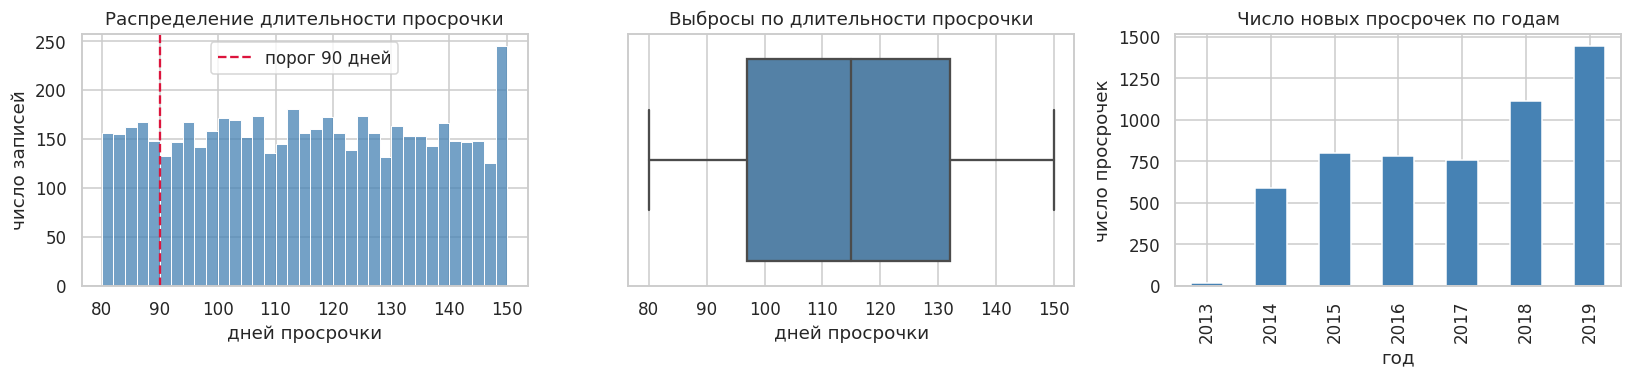

In [8]:
overdue_stats = loan['просрочка_дней'].describe().to_frame('просрочка_дней').T
overdue_stats.columns.name = 'Длительность просрочки: описательные статистики'
display(overdue_stats)

overdue_summary = pd.Series(
    {
        'записей о просрочках': len(loan),
        'уникальных клиентов': loan['ID'].nunique(),
        'эпизодов < 90 дней': int(
            (loan['просрочка_дней'] < MIN_DEFAULT_DAYS).sum()
        ),
        'эпизодов >= 90 дней': int(
            (loan['просрочка_дней'] >= MIN_DEFAULT_DAYS).sum()
        ),
        'клиентов с дефолтом >= 90 дней': loan.loc[
            loan['просрочка_дней'] >= MIN_DEFAULT_DAYS, 'ID'
        ].nunique(),
        'доля клиентов банка с дефолтом': round(
            loan.loc[
                loan['просрочка_дней'] >= MIN_DEFAULT_DAYS, 'ID'
            ].nunique()
            / client['ID'].nunique(),
            4,
        ),
        'первая дата просрочки': loan['дата_начала_периода'].min().date(),
        'последняя дата просрочки': loan['дата_начала_периода'].max().date(),
    }
).to_frame('значение')
overdue_summary.columns.name = 'Просрочки'
display(overdue_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
sns.histplot(loan['просрочка_дней'], bins=35, ax=axes[0], color='steelblue')
axes[0].axvline(
    MIN_DEFAULT_DAYS, color='crimson', ls='--', label='порог 90 дней'
)
axes[0].set_title('Распределение длительности просрочки')
axes[0].set_xlabel('дней просрочки')
axes[0].set_ylabel('число записей')
axes[0].legend()

sns.boxplot(x=loan['просрочка_дней'], ax=axes[1], color='steelblue')
axes[1].set_title('Выбросы по длительности просрочки')
axes[1].set_xlabel('дней просрочки')

loan.groupby(
    loan['дата_начала_периода'].dt.to_period('Y').astype(str)
).size().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Число новых просрочек по годам')
axes[2].set_xlabel('год')
axes[2].set_ylabel('число просрочек')
plt.tight_layout()
plt.show()

### Клиенты и параметры кредитов

Клиенты и кредиты: описательные статистики,count,mean,std,min,25%,50%,75%,max
возраст,13500.0,41.3,15.1,18.0,28.0,40.0,54.0,69.0
доход,13500.0,79089.3,40045.5,15010.0,43347.0,77991.5,113615.5,149988.0
сумма_кредита,13500.0,1993383.5,1061381.4,75000.0,1079328.8,2032732.5,2919236.2,3749400.0


Проверка выбросов по правилу 1.5 IQR,p25,p75,нижний ус,верхний ус,за усами,max
возраст,28.0,54.0,-11.0,93.0,0.0,69.0
доход,43347.0,113615.5,-62055.8,219018.2,0.0,149988.0
сумма_кредита,1079328.8,2919236.2,-1680532.5,5679097.5,0.0,3749400.0


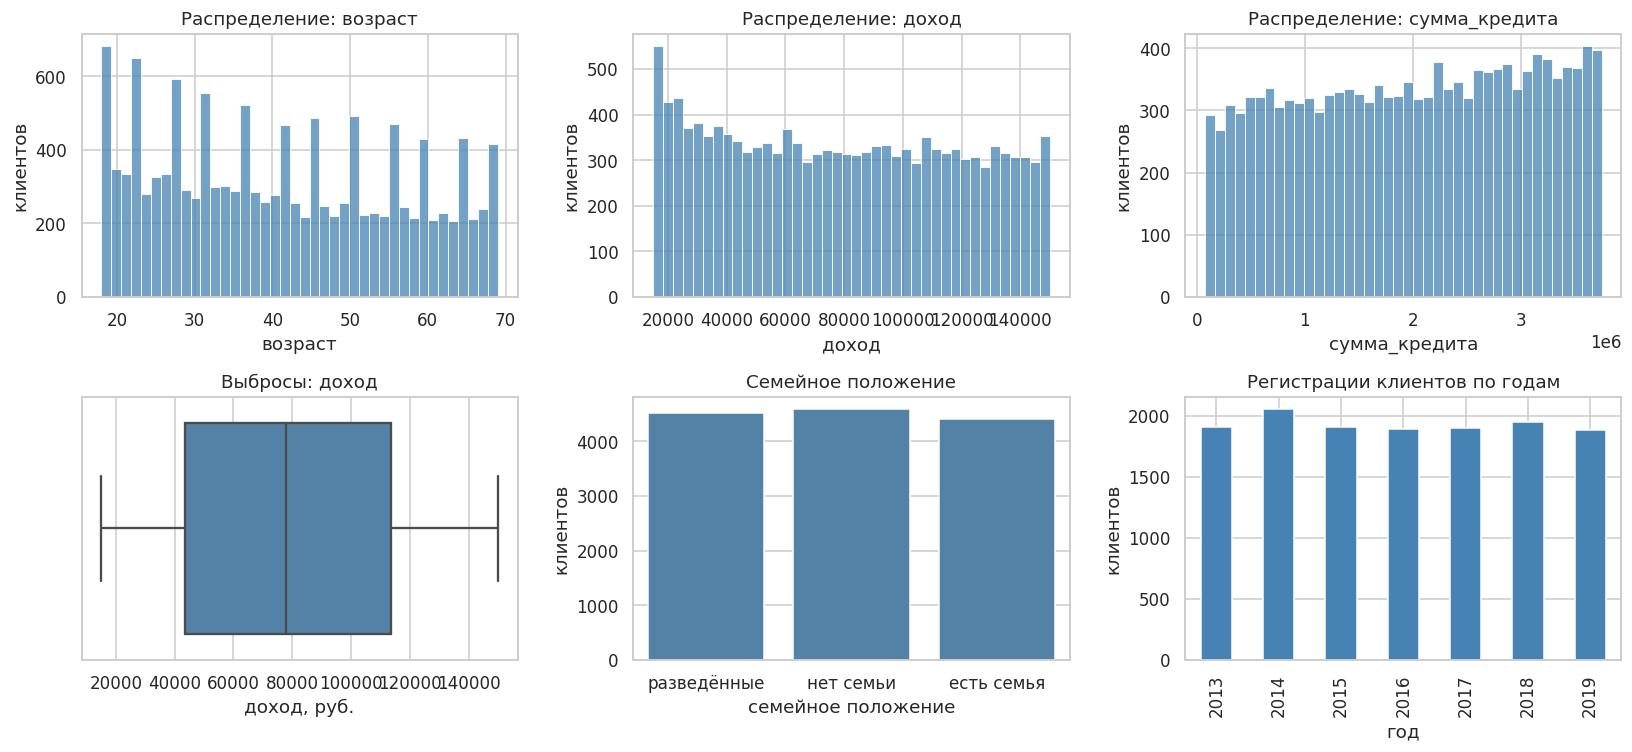

Распределение по семейному положению,доля
нет семьи,0.340
разведённые,0.335
есть семья,0.326


Распределение по наличию иждивенцев,доля
0,0.515
1,0.485


In [9]:
clients = client.merge(credit, on='ID', how='left')
clients_stats = clients[['возраст', 'доход', 'сумма_кредита']].describe().T
clients_stats.columns.name = 'Клиенты и кредиты: описательные статистики'
display(clients_stats.round(1))


def iqr_report(s):
    """Границы усов и число наблюдений за ними:
    формальная проверка на выбросы."""
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series(
        {
            'p25': q1,
            'p75': q3,
            'нижний ус': low,
            'верхний ус': high,
            'за усами': int(((s < low) | (s > high)).sum()),
            'max': s.max(),
        },
        name=s.name,
    )


iqr_table = pd.DataFrame(
    [iqr_report(clients[c]) for c in ['возраст', 'доход', 'сумма_кредита']]
)
iqr_table.columns.name = 'Проверка выбросов по правилу 1.5 IQR'
display(iqr_table.round(1))

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes[0], ['возраст', 'доход', 'сумма_кредита']):
    sns.histplot(clients[col], bins=40, ax=ax, color='steelblue')
    ax.set_title(f'Распределение: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('клиентов')

sns.boxplot(x=clients['доход'], ax=axes[1][0], color='steelblue')
axes[1][0].set_title('Выбросы: доход')
axes[1][0].set_xlabel('доход, руб.')
sns.countplot(
    x='семейное_положение', data=clients, ax=axes[1][1], color='steelblue'
)
axes[1][1].set_title('Семейное положение')
axes[1][1].set_xlabel('семейное положение')
axes[1][1].set_ylabel('клиентов')
client.groupby(
    client['дата_регистрации'].dt.to_period('Y').astype(str)
).size().plot(kind='bar', ax=axes[1][2], color='steelblue')
axes[1][2].set_title('Регистрации клиентов по годам')
axes[1][2].set_xlabel('год')
axes[1][2].set_ylabel('клиентов')
plt.tight_layout()
plt.show()

family_status_share = (
    client['семейное_положение']
    .value_counts(normalize=True)
    .round(3)
    .to_frame('доля')
)
family_status_share.columns.name = 'Распределение по семейному положению'
display(family_status_share)

dependants_share = (
    client['наличие_иждивенцев']
    .value_counts(normalize=True)
    .round(3)
    .to_frame('доля')
)
dependants_share.columns.name = 'Распределение по наличию иждивенцев'
display(dependants_share)

### Ипотека

In [10]:
mortgage_summary = pd.Series(
    {
        'записей': len(mortgage),
        'уникальных клиентов': mortgage['ID'].nunique(),
        'уникальных значений наличие_ипотеки': mortgage[
            'наличие_ипотеки'
        ].nunique(),
        'значения наличие_ипотеки': ', '.join(
            map(str, sorted(mortgage['наличие_ипотеки'].unique()))
        ),
        'клиентов без записи об ипотеке': client['ID'].nunique()
        - mortgage['ID'].nunique(),
        'первая дата открытия': mortgage['дата_открытия'].min().date(),
        'последняя дата открытия': mortgage['дата_открытия'].max().date(),
    }
).to_frame('значение')
mortgage_summary.columns.name = 'Ипотека'
display(mortgage_summary)

Ипотека,значение
записей,6609
уникальных клиентов,6609
уникальных значений наличие_ипотеки,1
значения наличие_ипотеки,1
клиентов без записи об ипотеке,6891
первая дата открытия,2013-01-01
последняя дата открытия,2019-12-01


### Транзакции по MCC-кодам

Месячные траты по MCC-кодам: описательные статистики,count,mean,std,min,25%,50%,75%,max
MCC_5300,577494.0,6177.1,8835.9,162.9,1360.9,2659.6,6561.5,86939.4
MCC_5814,577494.0,3507.7,5710.8,62.2,583.5,1233.1,3642.4,55720.7
MCC_5812,577494.0,2993.9,4541.1,67.1,611.5,1224.5,3201.6,47969.6
MCC_5411,577494.0,9263.1,12299.7,286.1,2139.5,4115.4,9287.5,101302.0
MCC_3990,577494.0,1128.1,1557.2,31.9,245.1,476.9,1159.5,14261.5
MCC_5722,577494.0,3604.4,5005.9,108.4,824.9,1590.1,3866.0,54630.2
MCC_4900,577494.0,3682.5,5568.0,81.3,700.6,1397.1,3872.4,52987.5
MCC_другое,577494.0,5414.9,7190.9,166.3,1250.8,2398.3,5413.5,60033.6


Нулевые траты по категориям,доля нулевых трат
MCC_5300,0.0
MCC_5814,0.0
MCC_5812,0.0
MCC_5411,0.0
MCC_3990,0.0
MCC_5722,0.0
MCC_4900,0.0
MCC_другое,0.0


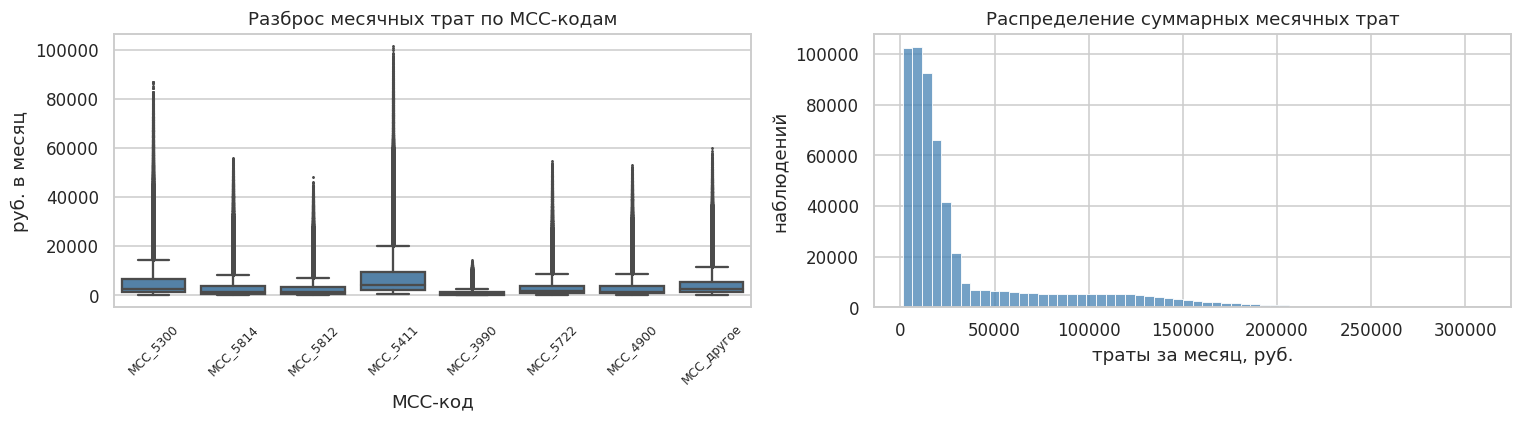

In [11]:
spending_stats = trans[MCC_COLS].describe().T.round(1)
spending_stats.columns.name = (
    'Месячные траты по MCC-кодам: описательные статистики'
)
display(spending_stats)

zero_share = (
    (trans[MCC_COLS] == 0).mean().round(4).to_frame('доля нулевых трат')
)
zero_share.columns.name = 'Нулевые траты по категориям'
display(zero_share)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=trans[MCC_COLS], ax=axes[0], color='steelblue', fliersize=1)
axes[0].set_title('Разброс месячных трат по MCC-кодам')
axes[0].set_xlabel('MCC-код')
axes[0].set_ylabel('руб. в месяц')
axes[0].tick_params(axis='x', labelrotation=45, labelsize=8)

sns.histplot(
    trans[MCC_COLS].sum(axis=1), bins=60, ax=axes[1], color='steelblue'
)
axes[1].set_title('Распределение суммарных месячных трат')
axes[1].set_xlabel('траты за месяц, руб.')
axes[1].set_ylabel('наблюдений')
plt.tight_layout()
plt.show()

### Структура панели наблюдений (cohort_grid)

Проверяем, что сетка скоринга - это регулярная месячная панель: шаг между наблюдениями, длина
истории на клиента, совпадение первого месяца панели с датой регистрации и совпадение самой сетки
с сеткой транзакций.

Структура панели наблюдений,значение
"шаг между наблюдениями, дней",28 - 31 (календарный месяц)
месяцев на клиента: минимум,1
месяцев на клиента: медиана,43
месяцев на клиента: максимум,84
первый месяц панели = дата регистрации,100%
общий период,2013-01-01 - 2019-12-01
совпадение сетки cohort_grid и transactions,True


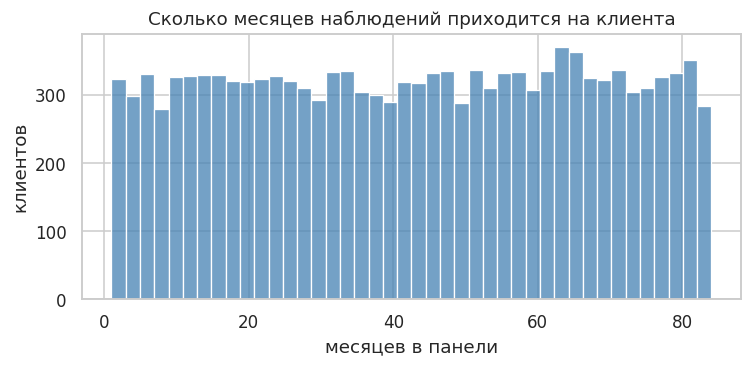

In [12]:
panel = cohort.sort_values(['ID', 'score_date'])
step_days = panel.groupby('ID')['score_date'].diff().dt.days.dropna()
panel_length = panel.groupby('ID').size()
first_month = panel.groupby('ID')['score_date'].min()
registration_date = client.set_index('ID')['дата_регистрации']
registration_match = (
    first_month == registration_date.reindex(first_month.index)
).mean()

panel_summary = pd.Series(
    {
        'шаг между наблюдениями, дней': (
            f'{int(step_days.min())} - {int(step_days.max())}'
            ' (календарный месяц)'
        ),
        'месяцев на клиента: минимум': int(panel_length.min()),
        'месяцев на клиента: медиана': int(panel_length.median()),
        'месяцев на клиента: максимум': int(panel_length.max()),
        'первый месяц панели = дата регистрации': (
            f'{registration_match:.0%}'
        ),
        'общий период': (
            f"{cohort['score_date'].min().date()}"
            f" - {cohort['score_date'].max().date()}"
        ),
        'совпадение сетки cohort_grid и transactions': set(
            map(tuple, cohort[['ID', 'score_date']].values)
        )
        == set(map(tuple, trans[['ID', 'date']].values)),
    }
).to_frame('значение')
panel_summary.columns.name = 'Структура панели наблюдений'
display(panel_summary)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(panel_length, bins=42, ax=ax, color='steelblue')
ax.set_title('Сколько месяцев наблюдений приходится на клиента')
ax.set_xlabel('месяцев в панели')
ax.set_ylabel('клиентов')
plt.tight_layout()
plt.show()

### Кредитный рейтинг

Кредитный рейтинг: описательные статистики,count,mean,std,min,25%,50%,75%,max
кредитный_рейтинг,577494.0,603.2,64.4,343.0,558.0,600.0,646.0,900.0


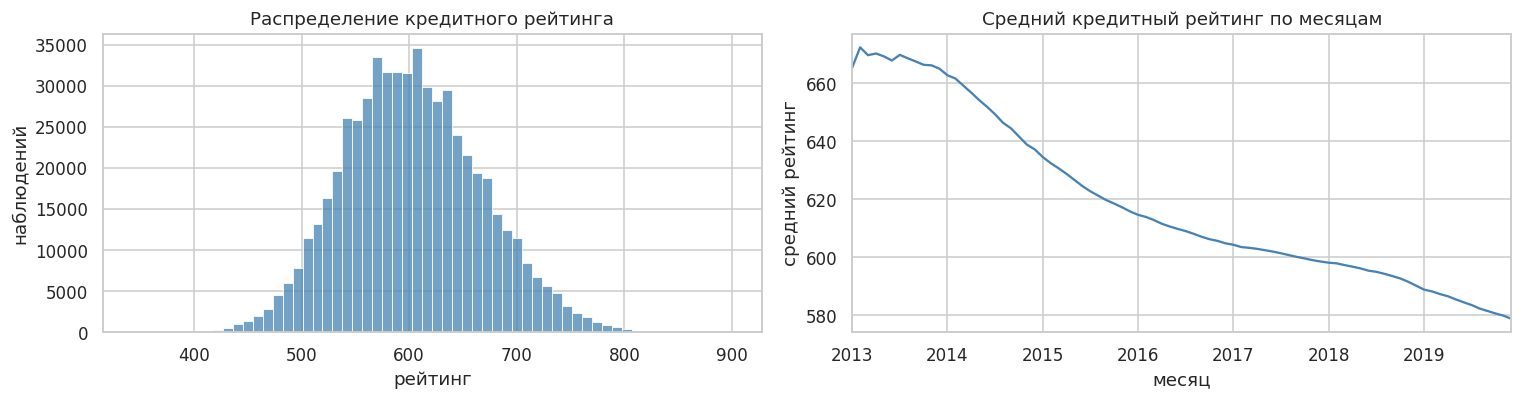

In [13]:
rating_stats = (
    rating['кредитный_рейтинг']
    .describe()
    .to_frame('кредитный_рейтинг')
    .T.round(1)
)
rating_stats.columns.name = 'Кредитный рейтинг: описательные статистики'
display(rating_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
sns.histplot(
    rating['кредитный_рейтинг'], bins=60, ax=axes[0], color='steelblue'
)
axes[0].set_title('Распределение кредитного рейтинга')
axes[0].set_xlabel('рейтинг')
axes[0].set_ylabel('наблюдений')

rating.groupby('date')['кредитный_рейтинг'].mean().plot(
    ax=axes[1], color='steelblue'
)
axes[1].set_title('Средний кредитный рейтинг по месяцам')
axes[1].set_xlabel('месяц')
axes[1].set_ylabel('средний рейтинг')
plt.tight_layout()
plt.show()

### Макроэкономические показатели

Макроэкономические показатели: описательные статистики,count,mean,std,min,25%,50%,75%,max
учетная_ставка,84.0,8.64,2.47,5.50,7.25,7.75,10.33,17.00
уровень_безработицы,84.0,5.18,0.41,4.30,4.90,5.20,5.50,6.00
инфляция,84.0,0.53,0.57,-0.54,0.26,0.42,0.64,3.85


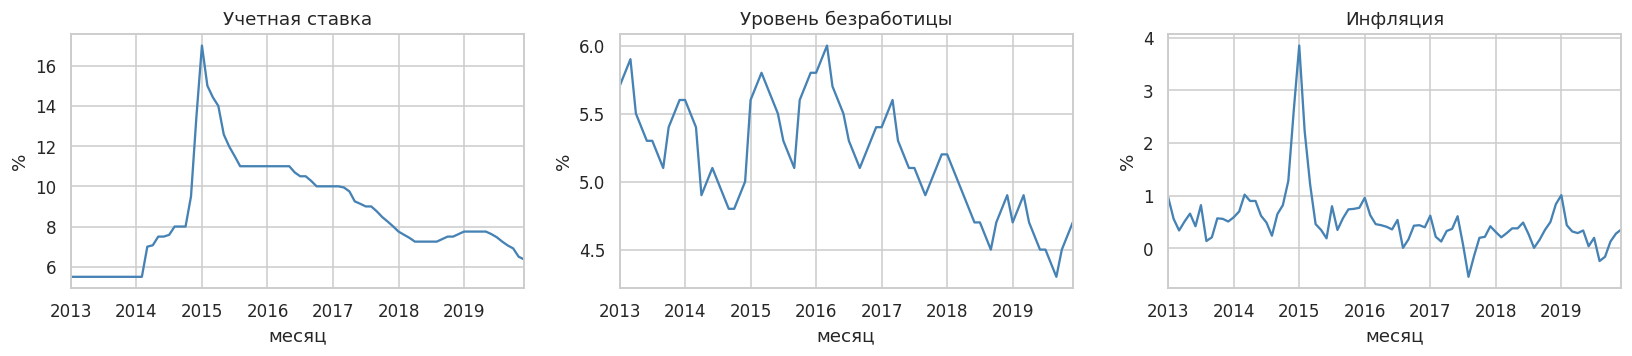

In [14]:
macro_stats = macro.describe().T.round(2)
macro_stats.columns.name = (
    'Макроэкономические показатели: описательные статистики'
)
display(macro_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, col in zip(
    axes, ['учетная_ставка', 'уровень_безработицы', 'инфляция']
):
    macro.set_index('date')[col].plot(ax=ax, color='steelblue')
    ax.set_title(col.replace('_', ' ').capitalize())
    ax.set_xlabel('месяц')
    ax.set_ylabel('%')
plt.tight_layout()
plt.show()

### Выводы по исследовательскому анализу данных

**Качество данных.** Во всех восьми таблицах **нет ни одного пропуска и ни одного полного
дубликата**. Ключ каждой таблицы уникален - проверено явно и подкреплено `assert`: `ID` в
справочниках клиентов, кредитов, ипотеки и просрочек, `ID + date` в транзакциях и кредитном
рейтинге, `ID + score_date` в сетке скоринга, `date` в макроэкономике. Идентификаторы согласованы:
в каждой таблице встречаются только те `ID`, что есть в справочнике клиентов.

**Структура наблюдений.** `cohort_grid`, `transactions` и `credit_rating` содержат одинаковую сетку
из 577 494 пар «клиент - месяц» (проверено сравнением множеств): это регулярная месячная панель за
2013-01 - 2019-12 по 13 500 клиентам. Шаг между наблюдениями - календарный месяц (28-31 день),
первый месяц панели совпадает с датой регистрации у 100% клиентов, длина истории от 1 до 84 месяцев
при медиане 43 месяца. Панель начинается с момента прихода клиента в банк, поэтому у «молодых»
клиентов истории мало - это придётся учесть при построении лаговых признаков.

**Просрочки.** 5 500 записей, ровно по одной на клиента - то есть в данных зафиксирован только
один эпизод просрочки на человека. Длительность 80-150 дней (медиана 115). Порогу дефолта не
удовлетворяют 788 эпизодов (< 90 дней), поэтому дефолтом считаем 4 712 клиентов - **34.9% всей
клиентской базы**. Первая просрочка датирована 2013-11, последняя - 2019-12.

**Клиенты и кредиты.** Возраст 18-69 лет (среднее 41.3), доход 15 010 - 149 988 руб. (медиана
77 992), сумма кредита 75 000 - 3 749 400 руб. (медиана 2 032 733). Проверка по правилу 1.5 IQR
даёт **ноль наблюдений за усами** по всем трём признакам: распределения равномерные, выбросов нет.
Категории сбалансированы: семейное положение делится примерно поровну (0.340 / 0.335 / 0.326),
иждивенцы есть у 48.5% клиентов.

**Ипотека.** Таблица содержит только записи со значением 1 (6 609 клиентов). У остальных 6 891
клиента записи нет - это означает не пропуск, а отсутствие ипотеки, поэтому после объединения
безопасно заполняем нулём. Даты открытия покрывают весь период, значит признак нужно строить
на дату скоринга, а не брать факт из будущего.

**Транзакции.** Нулевых трат нет ни в одной категории - клиенты тратят каждый месяц во всех восьми
группах MCC. Распределения сильно скошены вправо: крупнейшая категория - супермаркеты (среднее
9 263 руб. при максимуме 101 302), самая мелкая - экосистема Яндекса (среднее 1 128). Верхние
значения - это не ошибки, а хвост крупных трат, поэтому обрезать их не будем: масштабирование
и деревья справятся сами.

**Кредитный рейтинг.** Диапазон 343-900 при среднем 603, помесячная динамика без разрывов и
аномальных скачков.

**Макроэкономика.** 84 месяца без пропусков: учётная ставка 5.5-17% (пик - кризис конца 2014
года), безработица 4.3-6.0%, месячная инфляция от -0.54% до 3.85%.

**Ключевой вывод.** Данные чистые и полные, предобработка сводится к корректному объединению.
Главный риск проекта - не качество данных, а **утечка из будущего**: все таблицы, кроме
справочников, содержат помесячную историю, и её нужно аккуратно сдвигать относительно даты скоринга.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Дополнительно зафиксируй проверки уникальности ключей:

    ID в статических таблицах
    ID + date в транзакциях и рейтинге
    ID + score_date в сетке скоринга
    date в макроэкономике

Сравнение множеств подтверждает совпадение пар, но не исключает их дублирование внутри отдельной таблицы

<div class="alert alert-info"> <b>Комментарий студента:</b>

**Проверка добавлена** - раздел «Уникальность ключей» в исследовательском анализе (таблица
«Уникальность ключей таблиц» + `assert`). Ключи проверены ровно в предложенном разрезе:

* `ID` - в `client`, `credit`, `mortgage` и `loan`;
* `ID + date` - в `transactions` и `credit_rating`;
* `ID + score_date` - в `cohort_grid`;
* `date` - в `macro_data`.

Дублей ключа нет ни в одной из восьми таблиц, поэтому совпадение множеств пар теперь подкреплено
проверкой уникальности внутри каждой таблицы. Вывод по разделу дополнен этим результатом.
</div>


## Объединение таблиц

### Формирование целевой переменной

Логика полностью повторяет инструкцию к проекту:

1. Для каждого клиента находим **первый по времени** эпизод просрочки длительностью от 90 дней -
   дату начала этого эпизода считаем датой дефолта. Так задано в инструкции: событие датируется
   полем `дата_начала_периода` строки, у которой `просрочка_дней >= 90`, а не моментом, когда
   счётчик просрочки дойдёт до 90 дней.
2. `target = 1`, если дата дефолта попадает в интервал `[score_date, score_date + 365 дней)`.
3. Удаляем строки, где дефолт уже случился к моменту скоринга (`дата_дефолта < score_date`):
   инструкция требует этого явно, и по смыслу поведенческий скоринг для уже дефолтного клиента
   не нужен - его судьбой занимается не скоринг, а взыскание.
4. Дополнительно удаляем строки, у которых **горизонт наблюдения неполный**. Последняя просрочка
   в данных зафиксирована на `2019-12-01`, а горизонт таргета - ровно 12 месяцев, поэтому он
   полностью наблюдаем только для дат скоринга **по `2018-12-01` включительно**
   (`последняя_просрочка - 12 месяцев`, то же самое, что условие `score_date < 2019-01-01`).
   Более поздние строки получили бы ложный `target = 0`: часть их горизонта в данные не попала.

**Важное следствие для оценки качества.** Горизонт таргета длиной год означает, что метка строки
месяца `t` зависит от событий месяцев `t...t+12`. При стыке выборок встык (как требует
постановка задачи: калибровка и тест - по 12 месяцев) горизонты пограничных строк обучающей
выборки заходят на территорию калибровочной. Мы фиксируем это как известное ограничение оценки и
возвращаемся к нему в выводах.

In [15]:
defaults = (
    loan.loc[loan['просрочка_дней'] >= MIN_DEFAULT_DAYS]
    .groupby('ID', as_index=False)['дата_начала_периода']
    .min()
    .rename(columns={'дата_начала_периода': 'дата_дефолта'})
)

df = cohort.merge(defaults, on='ID', how='left')
horizon_end = df['score_date'] + pd.Timedelta(days=HORIZON_DAYS)
df['target'] = (
    (df['дата_дефолта'] >= df['score_date'])
    & (df['дата_дефолта'] < horizon_end)
).astype(int)

steps = [('исходная сетка cohort_grid', len(df), df['target'].mean())]

df = df.loc[~(df['дата_дефолта'] < df['score_date'])].copy()
steps.append(
    ('после удаления уже случившихся дефолтов', len(df), df['target'].mean())
)

last_default_date = loan['дата_начала_периода'].max()
# горизонт таргета - полные 12 месяцев, поэтому последняя допустимая дата
# скоринга отстоит от последней просрочки ровно на горизонт:
# 2019-12-01 - 12 мес = 2018-12-01 (эквивалентно score_date < 2019-01-01)
last_full_month = last_default_date - pd.DateOffset(months=HORIZON_MONTHS)
df = df.loc[df['score_date'] <= last_full_month].copy()
steps.append(
    ('после удаления неполного горизонта', len(df), df['target'].mean())
)

report = pd.DataFrame(steps, columns=['шаг', 'строк', 'доля target=1'])
report['доля target=1'] = report['доля target=1'].round(4)
report.columns.name = (
    f'Фильтрация наблюдений (последний полный месяц: {last_full_month.date()})'
)
display(report)

Фильтрация наблюдений (последний полный месяц: 2018-12-01),шаг,строк,доля target=1
0,исходная сетка cohort_grid,577494,0.0855
1,после удаления уже случившихся дефолтов,438379,0.1126
2,после удаления неполного горизонта,334696,0.1326


In [16]:
example_id = defaults.loc[
    defaults['дата_дефолта'].between('2016-01-01', '2016-06-01'), 'ID'
].iloc[0]
example_default_date = defaults.loc[
    defaults['ID'] == example_id, 'дата_дефолта'
].iloc[0]
example = (
    cohort.loc[cohort['ID'] == example_id]
    .merge(defaults, on='ID', how='left')
    .assign(
        target=lambda d: (
            (d['дата_дефолта'] >= d['score_date'])
            & (
                d['дата_дефолта']
                < d['score_date'] + pd.Timedelta(days=HORIZON_DAYS)
            )
        ).astype(int),
        **{
            'строка_удалена': lambda d: np.where(
                d['дата_дефолта'] < d['score_date'],
                'да, дефолт уже произошёл',
                'нет',
            )
        },
    )
)
example = example.loc[
    example['score_date'].between(
        example_default_date - pd.DateOffset(months=14),
        example_default_date + pd.DateOffset(months=2),
    )
]
example.columns.name = (
    f'Проверка целевой переменной: клиент {example_id}, '
    f'дата дефолта {example_default_date.date()}'
)
display(example)

"Проверка целевой переменной: клиент IDF54899429, дата дефолта 2016-03-01",ID,score_date,дата_дефолта,target,строка_удалена
6,IDF54899429,2015-01-01,2016-03-01,0,нет
7,IDF54899429,2015-02-01,2016-03-01,0,нет
8,IDF54899429,2015-03-01,2016-03-01,0,нет
9,IDF54899429,2015-04-01,2016-03-01,1,нет
10,IDF54899429,2015-05-01,2016-03-01,1,нет
11,IDF54899429,2015-06-01,2016-03-01,1,нет
12,IDF54899429,2015-07-01,2016-03-01,1,нет
13,IDF54899429,2015-08-01,2016-03-01,1,нет
14,IDF54899429,2015-09-01,2016-03-01,1,нет
15,IDF54899429,2015-10-01,2016-03-01,1,нет


### Сборка признаков без утечки из будущего

Все помесячные источники сдвигаем минимум на один месяц назад: значение за месяц `t` описывает
завершившийся месяц и становится известно банку только после его окончания, поэтому для скоринга
на `score_date` доступны данные месяца `score_date - 1` и раньше.

* **Транзакции:** траты предыдущего месяца, средние траты за 3 предыдущих месяца, разброс трат за
  6 предыдущих месяцев, структура трат по MCC-кодам.
* **Кредитный рейтинг:** значение за предыдущий месяц, минимум за 6 предыдущих месяцев, изменение
  за квартал. Если истории меньше квартала, точкой отсчёта служит первый известный рейтинг клиента.
* **Макроэкономика:** показатели предыдущего месяца плюс изменение ставки за год.
* **Ипотека:** флаг «ипотека уже оформлена на дату скоринга», а не факт из будущего.

In [17]:
trans_s = trans.sort_values(['ID', 'date']).reset_index(drop=True)
trans_s['траты_всего'] = trans_s[MCC_COLS].sum(axis=1)
gt = trans_s.groupby('ID')

spending_features = trans_s[['ID', 'date']].copy()
spending_features['траты_всего_1м'] = gt['траты_всего'].shift(1)
spending_features['траты_средние_3м'] = gt['траты_всего'].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)
spending_features['траты_разброс_6м'] = gt['траты_всего'].transform(
    lambda s: s.shift(1).rolling(6, min_periods=2).std()
)
for col in MCC_COLS:
    spending_features[f'доля_{col}'] = (
        gt[col].shift(1) / spending_features['траты_всего_1м']
    )

rating_s = rating.sort_values(['ID', 'date']).reset_index(drop=True)
gr = rating_s.groupby('ID')['кредитный_рейтинг']
rating_features = rating_s[['ID', 'date']].copy()
rating_features['рейтинг_1м'] = gr.shift(1)
rating_features['рейтинг_минимум_6м'] = gr.transform(
    lambda s: s.shift(1).rolling(6, min_periods=1).min()
)
# сдвиг на 4 месяца = рейтинг за квартал до последнего доступного месяца;
# если истории меньше, точкой отсчёта берём первый известный рейтинг клиента
rating_quarter_ago = gr.shift(4).fillna(gr.transform('first'))
rating_features['рейтинг_изменение_3м'] = (
    rating_features['рейтинг_1м'] - rating_quarter_ago
)

macro_s = macro.sort_values('date').reset_index(drop=True)
macro_s['ставка_изменение_12м'] = macro_s['учетная_ставка'] - macro_s[
    'учетная_ставка'
].shift(12).fillna(macro_s['учетная_ставка'].iloc[0])
macro_s['score_date'] = macro_s['date'] + pd.DateOffset(months=1)
macro_features = macro_s.drop(columns=['date'])

df = (
    df.merge(
        spending_features,
        left_on=['ID', 'score_date'],
        right_on=['ID', 'date'],
        how='left',
    )
    .drop(columns='date')
    .merge(
        rating_features,
        left_on=['ID', 'score_date'],
        right_on=['ID', 'date'],
        how='left',
    )
    .drop(columns='date')
    .merge(macro_features, on='score_date', how='left')
    .merge(client, on='ID', how='left')
    .merge(credit, on='ID', how='left')
    .merge(mortgage, on='ID', how='left')
)

rows_before = len(df)
df = df.loc[df['траты_всего_1м'].notna() & df['рейтинг_1м'].notna()].copy()
print(
    f'Удалено строк без истории (первый месяц клиента):'
    f' {rows_before - len(df)}; осталось: {len(df)}'
)

Удалено строк без истории (первый месяц клиента): 11613; осталось: 323083


Проверяем сборку признаков на том же клиенте: рядом кладём собранный признак и сырое значение
источника за **предыдущий** месяц. Если сдвиг сделан правильно, столбцы совпадут.

In [18]:
lag_check = df.loc[
    df['ID'] == example_id,
    ['score_date', 'траты_всего_1м', 'рейтинг_1м', 'учетная_ставка'],
].copy()
lag_check['месяц_источника'] = lag_check['score_date'] - pd.DateOffset(
    months=1
)

raw_spending = trans.assign(**{'траты_сырые': trans[MCC_COLS].sum(axis=1)})[
    ['ID', 'date', 'траты_сырые']
]
lag_check = (
    lag_check.merge(
        raw_spending.loc[raw_spending['ID'] == example_id].drop(columns='ID'),
        left_on='месяц_источника',
        right_on='date',
        how='left',
    )
    .drop(columns='date')
    .merge(
        rating.loc[
            rating['ID'] == example_id, ['date', 'кредитный_рейтинг']
        ].rename(columns={'кредитный_рейтинг': 'рейтинг_сырой'}),
        left_on='месяц_источника',
        right_on='date',
        how='left',
    )
    .drop(columns='date')
    .merge(
        macro[['date', 'учетная_ставка']].rename(
            columns={'учетная_ставка': 'ставка_сырая'}
        ),
        left_on='месяц_источника',
        right_on='date',
        how='left',
    )
    .drop(columns='date')
)

assert np.allclose(
    lag_check['траты_всего_1м'], lag_check['траты_сырые']
), 'Сдвиг трат нарушен'
assert (
    lag_check['рейтинг_1м'] == lag_check['рейтинг_сырой']
).all(), 'Сдвиг рейтинга нарушен'
assert np.allclose(
    lag_check['учетная_ставка'], lag_check['ставка_сырая']
), 'Сдвиг макро нарушен'

lag_check_sample = lag_check.head(6)
lag_check_sample.columns.name = (
    f'Проверка лагов на клиенте {example_id}: признак против сырого источника'
)
display(lag_check_sample)
print(
    'Проверка: все помесячные признаки взяты за месяц до даты скоринга - '
    'пройдена'
)

Проверка лагов на клиенте IDF54899429: признак против сырого источника,score_date,траты_всего_1м,рейтинг_1м,учетная_ставка,месяц_источника,траты_сырые,рейтинг_сырой,ставка_сырая
0,2014-08-01,26400.25,710.0,7.586957,2014-07-01,26400.25,710,7.586957
1,2014-09-01,29323.15,712.0,8.000000,2014-08-01,29323.15,712,8.000000
2,2014-10-01,29538.73,702.0,8.000000,2014-09-01,29538.73,702,8.000000
3,2014-11-01,28544.75,687.0,8.000000,2014-10-01,28544.75,687,8.000000
4,2014-12-01,29596.76,690.0,9.500000,2014-11-01,29596.76,690,9.500000
5,2015-01-01,32948.19,687.0,13.500000,2014-12-01,32948.19,687,13.500000


Проверка: все помесячные признаки взяты за месяц до даты скоринга - пройдена


### Выводы по объединению таблиц

**Фильтрация.** Из исходных 577 494 строк сетки скоринга осталось 323 083:

1. **-139 115 строк (24.1%)** - наблюдения после уже случившегося дефолта. Их удаление требует
   инструкция; по смыслу такие клиенты выбывают из поведенческого скоринга и переходят к взысканию.
2. **-103 683 строки** - месяцы скоринга после `2018-12-01`, у которых 12-месячный горизонт выходит
   за границу наблюдаемых данных (последняя просрочка в данных - 2019-12-01). Без этой обрезки
   такие строки получили бы ложный `target = 0` и занизили бы долю дефолтов.
3. **-11 613 строк** - первый месяц каждого клиента, для которого нет ни одного месяца истории,
   поэтому лаговые признаки не определены.

Доля целевого класса при этом закономерно росла: 8.55% → 11.26% → 13.26%.

**Проверка на конкретном клиенте.** Для клиента `IDF54899429` с датой дефолта 2016-03-01 таргет
равен 1 ровно в двенадцати месяцах с 2015-04 по 2016-03, до этого - 0, а строки после даты дефолта
удалены. Это в точности та логика скользящего окна, которая описана в постановке задачи.

**Итоговая мысль.** Витрина собрана по правилу «в строку с датой `score_date` попадает только
прошлое»: помесячные источники сдвинуты минимум на месяц назад, признак ипотеки построен на дату
скоринга, макроэкономика взята за предыдущий месяц, а горизонт целевой переменной наблюдается
полностью для каждой оставшейся строки. Утечки из будущего в признаках нет.


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Target рассчитывается через:

    score_date + pd.Timedelta(days=365)

Но последняя допустимая дата скоринга определяется так:

    last_full_month = (
        last_default_date
        - pd.DateOffset(months=HORIZON_MONTHS - 1)
    )

То есть из декабря 2019 года вычитается только 11 месяцев, и в витрине остаётся январь 2019 года. Это не согласуется с используемым горизонтом в 365 дней. История дефолтов заканчивается 2019-12-01, поэтому для полного годового горизонта безопасно оставить даты скоринга только до конца 2018 года:

    df = df[
        df["score_date"] < pd.Timestamp("2019-01-01")
    ].copy()

После этого test должен содержать полный 2018 год

<div class="alert alert-info"> <b>Комментарий студента:</b>

**Исправлено.** Ошибка была именно в арифметике: из даты последней просрочки вычитались 11 месяцев
вместо полного горизонта. Теперь:

```python
last_full_month = last_default_date - pd.DateOffset(months=HORIZON_MONTHS)
df = df.loc[df['score_date'] <= last_full_month].copy()
```

`2019-12-01 - 12 месяцев = 2018-12-01`, то есть условие полностью совпадает с предложенным
`score_date < pd.Timestamp("2019-01-01")`. Форму с `HORIZON_MONTHS` оставил, чтобы граница
пересчитывалась сама при смене горизонта, а не была зашита константой.

**Что изменилось дальше по тетради:** последний месяц витрины - `2018-12`, тестовая выборка -
**полный 2018 год** (2018-01 - 2018-12), калибровочная - 2017 год, обучающая - 2013-02 - 2016-12.
Все числа в выводах пересчитаны по новому прогону.
</div>


## Создание новых признаков

Добавляем признаки, которые описывают поведение клиента, а не только его статику на момент выдачи
кредита:

1. `долговая_нагрузка` - сумма кредита к месячному доходу;
2. `траты_к_доходу` - траты прошлого месяца к доходу;
3. `тренд_трат` - траты прошлого месяца к среднему за 3 предыдущих месяца;
4. `волатильность_трат` - разброс трат за полгода к их среднему уровню;
5. `рейтинг_изменение_3м` - динамика кредитного рейтинга за квартал;
6. `рейтинг_минимум_6м` - худшее значение рейтинга за полгода;
7. `доля_обязательных_трат` - доля продуктов и ЖКХ в тратах;
8. `стаж_в_банке_мес` и `возраст_на_дату_скоринга` - положение клиента на временной оси;
9. `ипотека_стаж_мес` - сколько месяцев назад оформлена ипотека.

Чтобы не дублировать информацию, из витрины убираем компоненты, из которых собраны отношения:
`сумма_кредита` (остаются `доход` и `долговая_нагрузка`), абсолютные траты (остаются доли и
`траты_к_доходу`) и одну из долей MCC, поскольку доли в сумме дают единицу.

In [19]:
df['наличие_ипотеки'] = (
    (df['наличие_ипотеки'] == 1) & (df['дата_открытия'] <= df['score_date'])
).astype(int)
df['ипотека_стаж_мес'] = np.where(
    df['наличие_ипотеки'] == 1,
    ((df['score_date'] - df['дата_открытия']).dt.days / 30.44).round(),
    0.0,
)
df['стаж_в_банке_мес'] = (
    (df['score_date'] - df['дата_регистрации']).dt.days / 30.44
).round()
df['возраст_на_дату_скоринга'] = df['возраст'] + df['стаж_в_банке_мес'] / 12
df['долговая_нагрузка'] = df['сумма_кредита'] / df['доход']
df['траты_к_доходу'] = df['траты_всего_1м'] / df['доход']
df['тренд_трат'] = df['траты_всего_1м'] / df['траты_средние_3м']
df['волатильность_трат'] = (
    df['траты_разброс_6м'] / df['траты_средние_3м']
).fillna(0.0)
df['доля_обязательных_трат'] = df['доля_MCC_5411'] + df['доля_MCC_4900']

df = df.drop(
    columns=[
        'дата_дефолта',
        'дата_регистрации',
        'дата_открытия',
        'сумма_кредита',
        'возраст',
        'траты_всего_1м',
        'траты_средние_3м',
        'траты_разброс_6м',
        'доля_MCC_другое',
    ]
)

NEW_FEATURES = [
    'долговая_нагрузка',
    'траты_к_доходу',
    'тренд_трат',
    'волатильность_трат',
    'рейтинг_изменение_3м',
    'рейтинг_минимум_6м',
    'доля_обязательных_трат',
    'стаж_в_банке_мес',
    'возраст_на_дату_скоринга',
    'ипотека_стаж_мес',
]

class_comparison = (
    df.groupby('target')[NEW_FEATURES]
    .mean()
    .T.rename(columns={0: 'без дефолта', 1: 'дефолт в горизонте 12 мес'})
)
class_comparison['разница, %'] = (
    (
        class_comparison['дефолт в горизонте 12 мес']
        / class_comparison['без дефолта']
        - 1
    )
    * 100
).round(1)
class_comparison.columns.name = 'Средние значения новых признаков по классам'
display(class_comparison.round(3))

Средние значения новых признаков по классам,без дефолта,дефолт в горизонте 12 мес,"разница, %"
долговая_нагрузка,33.119,49.348,49.0
траты_к_доходу,0.542,1.215,124.0
тренд_трат,0.979,1.055,7.7
волатильность_трат,0.454,0.111,-75.5
рейтинг_изменение_3м,-6.222,-7.534,21.1
рейтинг_минимум_6м,604.020,651.829,7.9
доля_обязательных_трат,0.361,0.359,-0.6
стаж_в_банке_мес,23.562,9.018,-61.7
возраст_на_дату_скоринга,45.784,37.193,-18.8
ипотека_стаж_мес,11.722,4.196,-64.2


### Выводы по новым признакам

Сравнение средних по классам показывает, что новые признаки действительно разделяют клиентов:

* **`траты_к_доходу` - главный сигнал**: у будущих дефолтников 1.215 против 0.542, разница
  **+124%**. Клиент, который тратит больше своего месячного дохода, уходит в просрочку кратно чаще.
* **`стаж_в_банке_мес` - 9.0 месяца против 23.6 (-61.7%)**: дефолты концентрируются в первые месяцы
  после выдачи кредита. То же самое видно по `ипотека_стаж_мес` (-64.2%).
* **`долговая_нагрузка` - 49.3 против 33.1 (+49%)**: чем больше кредит относительно дохода,
  тем выше риск.
* **`волатильность_трат` - 0.111 против 0.454 (-75.5%)**: у будущих дефолтников траты, наоборот,
  стабильно высокие, без провалов. Это не «рваное» потребление, а устойчивая жизнь не по средствам.
* **`возраст_на_дату_скоринга` - 37.2 против 45.8 лет**: молодые заёмщики рискованнее.
* **`рейтинг_минимум_6м` ведёт себя контринтуитивно**: у будущих дефолтников он **выше**
  (651.8 против 604.0), хотя по смыслу рейтинга должно быть наоборот. Связь с целевой переменной
  есть и она сильная, но её знак обратный ожидаемому. Это не «слабый признак», а сигнал о
  проблеме в самом источнике: либо шкала внешнего рейтинга инвертирована, либо рейтинг обновляется
  уже после того, как банк реагирует на риск. Разбираться с этим нужно с поставщиком данных.

**Защита от мультиколлинеарности.** Из витрины удалены компоненты, из которых собраны отношения:
`сумма_кредита` (осталась `долговая_нагрузка` и `доход`), абсолютные суммы трат (остались доли и
`траты_к_доходу`) и одна из долей MCC, поскольку восемь долей в сумме дают единицу.

**Итоговая мысль.** Поведенческие признаки - соотношение трат и дохода, долговая нагрузка и стаж
отношений с банком - разделяют классы заметно сильнее, чем статические анкетные данные.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Рассчитаны долговая нагрузка, траты к доходу, тренд и волатильность трат
* Добавлены динамика и минимум кредитного рейтинга

## Анализ итоговой таблицы

In [20]:
structure = pd.DataFrame(
    {
        'тип': df.dtypes.astype(str),
        'пропусков': df.isna().sum(),
        'уникальных': df.nunique(),
    }
)
structure.columns.name = (
    f'Витрина: {df.shape[0]} строк x {df.shape[1]} столбцов'
)
display(structure)

assert df.isna().sum().sum() == 0, 'В витрине остались пропуски'

mart_stats = df.describe().T.round(3)
mart_stats.columns.name = 'Итоговая витрина: описательные статистики'
display(mart_stats)

Витрина: 323083 строк x 29 столбцов,тип,пропусков,уникальных
ID,object,0,11435
score_date,datetime64[ns],0,71
target,int64,0,2
доля_MCC_5300,float64,0,323081
доля_MCC_5814,float64,0,323082
доля_MCC_5812,float64,0,323080
доля_MCC_5411,float64,0,323082
доля_MCC_3990,float64,0,323078
доля_MCC_5722,float64,0,323082
доля_MCC_4900,float64,0,323081


Итоговая витрина: описательные статистики,count,mean,std,min,25%,50%,75%,max
target,323083.0,0.133,0.340,0.000,0.000,0.000,0.000,1.000
доля_MCC_5300,323083.0,0.173,0.057,0.103,0.133,0.146,0.193,0.335
доля_MCC_5814,323083.0,0.097,0.058,0.034,0.049,0.057,0.163,0.233
доля_MCC_5812,323083.0,0.083,0.035,0.043,0.057,0.062,0.098,0.173
доля_MCC_5411,323083.0,0.259,0.032,0.185,0.235,0.251,0.275,0.376
доля_MCC_3990,323083.0,0.031,0.008,0.018,0.025,0.028,0.041,0.057
доля_MCC_5722,323083.0,0.104,0.039,0.063,0.083,0.089,0.100,0.249
доля_MCC_4900,323083.0,0.102,0.050,0.048,0.065,0.073,0.157,0.220
рейтинг_1м,323083.0,618.702,67.275,367.000,571.000,618.000,666.000,900.000
рейтинг_минимум_6м,323083.0,610.381,68.067,367.000,562.000,610.000,658.000,900.000


"Баланс классов, дисбаланс 1:6.5",строк,доля
нет дефолта (0),280103,0.867
дефолт в горизонте 12 мес (1),42980,0.133


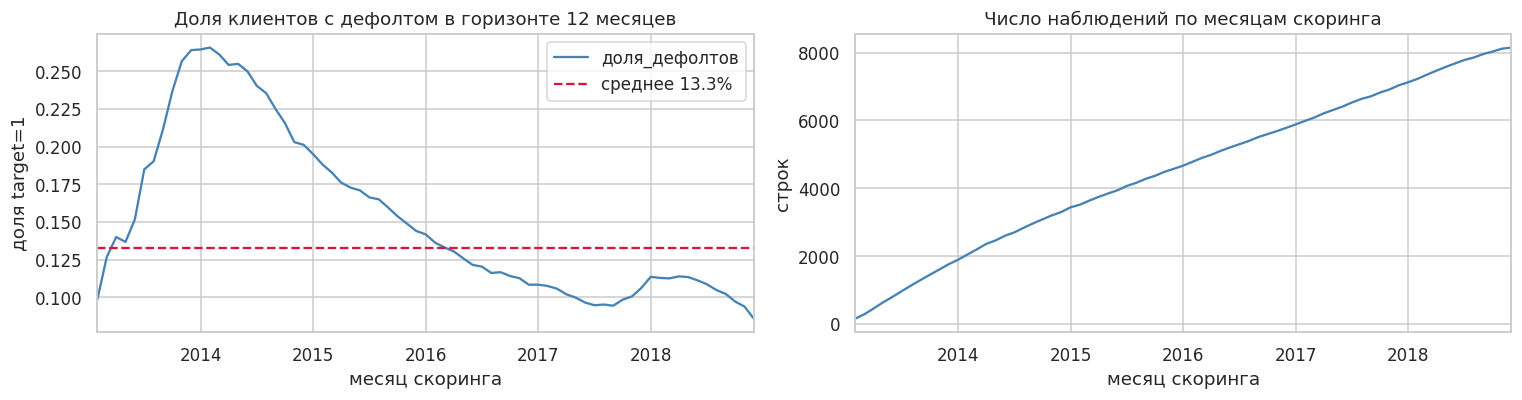

In [21]:
class_balance = df['target'].value_counts().to_frame('строк')
class_balance['доля'] = (class_balance['строк'] / len(df)).round(4)
class_balance.index = ['нет дефолта (0)', 'дефолт в горизонте 12 мес (1)']
imbalance_ratio = round(
    class_balance.loc['нет дефолта (0)', 'строк']
    / class_balance.loc['дефолт в горизонте 12 мес (1)', 'строк'],
    1,
)
class_balance.columns.name = (
    f'Баланс классов, дисбаланс 1:{imbalance_ratio}'
)
display(class_balance)

monthly = df.groupby('score_date').agg(
    **{'строк': ('target', 'size'), 'доля_дефолтов': ('target', 'mean')}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
monthly['доля_дефолтов'].plot(ax=axes[0], color='steelblue')
axes[0].axhline(
    df['target'].mean(),
    color='crimson',
    ls='--',
    label=f"среднее {df['target'].mean():.1%}",
)
axes[0].set_title('Доля клиентов с дефолтом в горизонте 12 месяцев')
axes[0].set_xlabel('месяц скоринга')
axes[0].set_ylabel('доля target=1')
axes[0].legend()

monthly['строк'].plot(ax=axes[1], color='steelblue')
axes[1].set_title('Число наблюдений по месяцам скоринга')
axes[1].set_xlabel('месяц скоринга')
axes[1].set_ylabel('строк')
plt.tight_layout()
plt.show()

### Выводы по итоговой таблице

**Размер и качество.** Витрина - 323 083 строки и 29 столбцов: 26 признаков, идентификатор клиента,
дата скоринга и таргет. Пропусков нет (проверено `assert`), типы корректные, в выборке 11 435
уникальных клиентов и 71 месяц скоринга (2013-02 - 2018-12).

**Баланс классов.** Дефолт в горизонте 12 месяцев ожидается у **13.30%** наблюдений
(42 980 строк против 280 103), дисбаланс **1:6.5**. Выводы отсюда два:

1. **accuracy как основная метрика непригодна** - модель, предсказывающая «дефолта не будет»
   всем подряд, получит 86.7% точности и нулевую пользу. Поэтому основными считаем ROC-AUC и
   бизнес-метрики.
2. **балансировка классов обязательна** - иначе модель почти не будет предсказывать редкий класс.
   Сравним `class_weight`, `RandomOverSampler`, `RandomUnderSampler` и `SMOTE`.

**Динамика во времени.** График доли дефолтов по месяцам показывает не плавный тренд, а горб:
уровень риска быстро растёт в 2013 году, достигает максимума в начале 2014 года и затем устойчиво
снижается до конца периода. Разрыв огромный - в обучающем периоде средняя доля дефолтов 16.6%,
а в калибровочном и тестовом уже 10.1% и 10.6% (см. таблицу разделения выборок ниже).
Портфель взрослеет, а вместе с ним меняется уровень риска, поэтому случайное перемешивание
данных недопустимо: выборки нарезаем строго по времени, иначе модель будет учиться на «будущем»
уровне дефолтности.

**Итоговая мысль.** Данные готовы к моделированию: пропусков нет, признаки поведенческие,
дисбаланс умеренный и лечится балансировкой, а временная структура требует хронологического
разделения выборок.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Корректно отмечена непригодность Accuracy как единственной метрики

## Моделирование

### Формирование выборок

Данные разделяем строго по времени, без перемешивания:

* **тестовая выборка** - последние 12 месяцев скоринга;
* **калибровочная выборка** - предыдущие 12 месяцев;
* **обучающая выборка** - вся более ранняя история.

Такое разделение имитирует реальную эксплуатацию: модель обучается на прошлом и применяется к
будущему. Выборки нарезаем не вручную, а тем же инструментом, который учитывает и группировку, и
время - `GroupTimeSeriesSplit()` с группой «месяц скоринга»: сначала отделяем 12 тестовых месяцев,
затем тем же способом отделяем 12 калибровочных от оставшейся истории. Внутри обучающей выборки
`GroupTimeSeriesSplit()` используется повторно - уже для трёх фолдов кросс-валидации.

In [22]:
df = df.sort_values(['score_date', 'ID']).reset_index(drop=True)
WINDOW = 12


def split_last_months(data, months):
    """GroupTimeSeriesSplit по группе «месяц скоринга»: прошлое уходит
    в первую часть, последние `months` месяцев - во вторую.
    Гарантирует, что вторая часть целиком лежит в будущем.
    """
    groups = data['score_date'].rank(method='dense').astype(int).values - 1
    splitter = GroupTimeSeriesSplit(test_size=months, n_splits=1)
    past_part, future_part = next(
        iter(splitter.split(data, data['target'], groups))
    )
    return data.iloc[past_part].reset_index(drop=True), data.iloc[
        future_part
    ].reset_index(drop=True)


train_and_calib, test = split_last_months(df, WINDOW)
train, calib = split_last_months(train_and_calib, WINDOW)

samples_table = pd.DataFrame(
    [
        {
            'выборка': name,
            'месяцев': part['score_date'].nunique(),
            'строк': len(part),
            'клиентов': part['ID'].nunique(),
            'доля target=1': round(part['target'].mean(), 4),
            'период': (
                f"{part['score_date'].min().date()}"
                f" - {part['score_date'].max().date()}"
            ),
        }
        for name, part in [
            ('обучающая', train),
            ('калибровочная', calib),
            ('тестовая', test),
        ]
    ]
)
samples_table.columns.name = 'Разделение выборок по времени'
display(samples_table)

assert (
    train['score_date'].max()
    < calib['score_date'].min()
    < test['score_date'].min()
)
print('Проверка: выборки не пересекаются во времени - пройдена')

Разделение выборок по времени,выборка,месяцев,строк,клиентов,доля target=1,период
0,обучающая,47,153186,7617,0.1660,2013-02-01 - 2016-12-01
1,калибровочная,12,77551,7633,0.1007,2017-01-01 - 2017-12-01
2,тестовая,12,92346,8899,0.1055,2018-01-01 - 2018-12-01


Проверка: выборки не пересекаются во времени - пройдена


**Ограничение, которое нужно измерить.** Метка строки зависит от событий следующих 12 месяцев,
поэтому у пограничных строк обучающей выборки горизонт таргета заходит в календарный период
калибровочной. Один и тот же эпизод просрочки при этом даёт до 12 положительных строк подряд, и
часть дефолтных клиентов встречается по обе стороны границы. Измерим масштаб эффекта - это
понадобится при интерпретации метрик.

In [23]:
def defaulted_clients(part):
    return set(part.loc[part['target'] == 1, 'ID'])


overlap_table = pd.DataFrame(
    [
        {
            'показатель': 'доля строк обучающей выборки, чей 12-месячный '
                          'горизонт заходит в период калибровочной',
            'значение': (
                train['score_date'] + pd.Timedelta(days=HORIZON_DAYS)
                > calib['score_date'].min()
            ).mean(),
        },
        {
            'показатель': 'доля дефолтных клиентов калибровочной выборки, уже '
                          'отмеченных дефолтом в обучающей',
            'значение': len(
                defaulted_clients(calib) & defaulted_clients(train)
            )
            / len(defaulted_clients(calib)),
        },
        {
            'показатель': 'доля дефолтных клиентов тестовой выборки, уже '
                          'отмеченных дефолтом в калибровочной',
            'значение': len(defaulted_clients(test) & defaulted_clients(calib))
            / len(defaulted_clients(test)),
        },
        {
            'показатель': 'доля дефолтных клиентов тестовой выборки, уже '
                          'отмеченных дефолтом в обучающей',
            'значение': len(defaulted_clients(test) & defaulted_clients(train))
            / len(defaulted_clients(test)),
        },
    ]
).set_index('показатель')
overlap_table.columns.name = (
    'Пересечение горизонтов целевой переменной между выборками'
)
display(overlap_table.round(4))

Пересечение горизонтов целевой переменной между выборками,значение
показатель,
"доля строк обучающей выборки, чей 12-месячный горизонт заходит в период калибровочной",0.3803
"доля дефолтных клиентов калибровочной выборки, уже отмеченных дефолтом в обучающей",0.4304
"доля дефолтных клиентов тестовой выборки, уже отмеченных дефолтом в калибровочной",0.4758
"доля дефолтных клиентов тестовой выборки, уже отмеченных дефолтом в обучающей",0.0000


### Пайплайн предобработки и схема кросс-валидации

Категориальный признак кодируем `OneHotEncoder(handle_unknown='ignore')` - на проде может
встретиться категория, которой не было в обучении. Числовые масштабируем `StandardScaler`. Оба
преобразования лежат внутри `Pipeline`, поэтому обучаются только на обучающей части каждого
фолда - утечки статистик из валидации нет.

**Схема кросс-валидации** - три непересекающихся **годовых** окна валидации:
`GroupTimeSeriesSplit(test_size=12, n_splits=3, shift_size=12, window_type='expanding')`. Длина окна
валидации совпадает и с горизонтом целевой переменной, и с длиной калибровочной и тестовой выборок,
поэтому оценка на фолде измеряет ровно тот режим, в котором модель будет работать. `shift_size=12`
сдвигает окно на его полную длину, `expanding` наращивает обучающую часть от фолда к фолду.

In [24]:
CATEGORICAL = ['семейное_положение']
NUMERIC = [
    c
    for c in df.columns
    if c not in CATEGORICAL + ['ID', 'score_date', 'target']
]

X_train, y_train = train[CATEGORICAL + NUMERIC], train['target']
X_test, y_test = test[CATEGORICAL + NUMERIC], test['target']
# калибровочная выборка делится на fit- и holdout-части в разделе о калибровке

train_groups = train['score_date'].rank(method='dense').astype(int).values - 1


def make_preprocessor():
    """Новый экземпляр препроцессора: OHE для категорий, стандартизация для
    числовых."""
    return ColumnTransformer(
        [
            ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
            ('num', StandardScaler(), NUMERIC),
        ]
    )


# годовое окно валидации: равно горизонту таргета и длине тестовой выборки.
# shift_size=12 сдвигает окно на его полную длину, поэтому окна трёх фолдов
# не пересекаются, а expanding наращивает обучающую часть
CV = GroupTimeSeriesSplit(
    test_size=12, n_splits=3, shift_size=12, window_type='expanding'
)
FOLDS = list(CV.split(X_train, y_train, train_groups))

folds_report = pd.DataFrame(
    [
        {
            'фолд': i + 1,
            'обучение: месяцы': (
                f'{train_groups[tr].min() + 1}'
                f'-{train_groups[tr].max() + 1}'
            ),
            'обучение: строк': len(tr),
            'валидация: месяцы': (
                f'{train_groups[va].min() + 1}'
                f'-{train_groups[va].max() + 1}'
            ),
            'валидация: строк': len(va),
            'доля target=1 на валидации': round(y_train.iloc[va].mean(), 4),
        }
        for i, (tr, va) in enumerate(FOLDS)
    ]
)
folds_report.columns.name = (
    f'GroupTimeSeriesSplit: {len(FOLDS)} фолда, группа = месяц скоринга'
)
display(folds_report)

windows = [set(train_groups[va]) for _, va in FOLDS]
assert all(
    not (a & b) for i, a in enumerate(windows) for b in windows[i + 1:]
), 'Окна валидации пересекаются'
print('Проверка: валидационные окна фолдов не пересекаются - пройдена')

"GroupTimeSeriesSplit: 3 фолда, группа = месяц скоринга",фолд,обучение: месяцы,обучение: строк,валидация: месяцы,валидация: строк,доля target=1 на валидации
0,1,1-11,10542,12-23,31650,0.2357
1,2,1-23,42192,24-35,48073,0.1673
2,3,1-35,90265,36-47,62921,0.1225


Проверка: валидационные окна фолдов не пересекаются - пройдена


### Метрики качества

Одобрение клиента - это предсказанный класс 0. Отсюда бизнес-метрики:

* **approval rate** = `(TN + FN) / N` - доля одобренных клиентов;
* **default rate** = `FN / (TN + FN)` - доля дефолтов внутри одобренных;
* **missed defaults rate** = `FN / (FN + TP)` - доля пропущенных дефолтов, равна `1 - recall`.

In [25]:
def business_metrics(y_true, y_pred):
    """Метрики банка: сколько одобрили, сколько дефолтов внутри одобренных и
    сколько пропустили."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    approved = y_pred == 0
    tn = int(((y_true == 0) & approved).sum())
    fn = int(((y_true == 1) & approved).sum())
    tp = int(((y_true == 1) & ~approved).sum())
    return {
        'approval_rate': approved.mean(),
        'default_rate': fn / max(tn + fn, 1),
        'missed_defaults_rate': fn / max(fn + tp, 1),
    }


def all_metrics(y_true, proba, threshold=0.5):
    """Технические и бизнес-метрики для одного порога отсечения."""
    y_pred = (proba >= threshold).astype(int)
    result = {
        'ROC_AUC': roc_auc_score(y_true, proba),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    result.update(business_metrics(y_true, y_pred))
    return result


def metrics_at_approval(y_true, proba, approval_share):
    """Метрики в точке, где банк одобряет заданную долю клиентов с наименьшим
    риском."""
    threshold = np.quantile(proba, approval_share)
    return business_metrics(y_true, (proba >= threshold).astype(int))


APPROVAL_LEVELS = [0.65, 0.70, 0.75, 0.80]
print('Функции метрик готовы')

Функции метрик готовы


### Базовые модели

Сравниваем четыре базовые конфигурации на кросс-валидации по трём фолдам: логистическую регрессию
и случайный лес, каждый - без балансировки и с `class_weight='balanced'`. Порог по умолчанию 0.5.

In [26]:
def evaluate_cv(model, label):
    """Кросс-валидация по временным фолдам: усредняем технические и бизнес-
    метрики."""
    rows = []
    for tr, va in FOLDS:
        model.fit(X_train.iloc[tr], y_train.iloc[tr])
        proba = model.predict_proba(X_train.iloc[va])[:, 1]
        metrics = all_metrics(y_train.iloc[va], proba)
        metrics['MDR при AR 65-80%'] = np.mean(
            [
                metrics_at_approval(y_train.iloc[va], proba, ar)[
                    'missed_defaults_rate'
                ]
                for ar in APPROVAL_LEVELS
            ]
        )
        rows.append(metrics)
    result = pd.DataFrame(rows).mean().to_dict()
    result['модель'] = label
    return result


baseline_models = {
    'Логистическая регрессия': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            (
                'clf',
                LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            ),
        ]
    ),
    'Логистическая регрессия + class_weight': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            (
                'clf',
                LogisticRegression(
                    max_iter=1000,
                    class_weight='balanced',
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    'Случайный лес': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            (
                'clf',
                RandomForestClassifier(
                    n_estimators=100,
                    min_samples_leaf=5,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    'Случайный лес + class_weight': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            (
                'clf',
                RandomForestClassifier(
                    n_estimators=100,
                    min_samples_leaf=5,
                    class_weight='balanced',
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

baseline_results = pd.DataFrame(
    [evaluate_cv(m, n) for n, m in baseline_models.items()]
)
baseline_results = baseline_results.set_index('модель')
baseline_results.columns.name = (
    'Базовые модели, среднее по 3 фолдам (порог 0.5)'
)
display(baseline_results.round(4))

"Базовые модели, среднее по 3 фолдам (порог 0.5)",ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate,MDR при AR 65-80%
модель,,,,,,,,,
Логистическая регрессия,0.7952,0.8071,0.4598,0.1995,0.2678,0.9086,0.1551,0.8005,0.3863
Логистическая регрессия + class_weight,0.8100,0.7379,0.3738,0.7271,0.4927,0.6588,0.0772,0.2729,0.3714
Случайный лес,0.8554,0.8360,0.5789,0.2439,0.3430,0.9253,0.1440,0.7561,0.2882
Случайный лес + class_weight,0.8599,0.8227,0.4934,0.5369,0.5138,0.8110,0.1027,0.4631,0.2875


### Выводы по базовым моделям

**Без балансировки модели бесполезны для банка.** При пороге 0.5 логистическая регрессия ловит
лишь 20.0% дефолтов (recall 0.1995), случайный лес - 24.4%. Approval rate 90.9% и 92.5% выглядят
прекрасно, но за ними прячется **missed defaults rate 80.1% и 75.6%**: три-четыре из пяти будущих
неплательщиков получают одобрение. Default rate внутри одобренных - 15.5% и 14.4%, что в семь
раз выше допустимых 2%.

**Балансировка радикально меняет картину.** С `class_weight='balanced'` логистическая регрессия
поднимает recall до 0.7271 (missed defaults rate 27.3%), случайный лес - до 0.5369 (46.3%). Ценой
становится approval rate: 65.9% и 81.1% соответственно.

**Случайный лес сильнее логистической регрессии** по разделяющей способности: ROC-AUC 0.8554-0.8599
против 0.7952-0.8100 в среднем по трём годовым фолдам. Разрыв объясняется нелинейностью
зависимостей: отношение трат к доходу и стаж работают «пороговыми» эффектами, которые линейная
модель не улавливает.

**Ключевая метрика проекта - missed defaults rate в рабочем диапазоне одобрений 65-80%** - тоже
за случайный лес: 0.2875 (с `class_weight`) и 0.2882 (без) против 0.3714 и 0.3863 у логистической
регрессии. Разница в 1.3 раза: при одинаковом объёме одобрений линейная модель пропускает
существенно больше дефолтов.

**Ключевой вывод.** Дальше работаем со случайным лесом, а порог 0.5 использовать не будем - его
подберём отдельно под бизнес-ограничения.


### Выбор метода балансировки классов

Дисбаланс классов лечим четырьмя способами и сравниваем их на одной и той же модели -
случайном лесе с фиксированными параметрами. Сравниваем по missed defaults rate в рабочем
диапазоне одобрений 65-80%: именно эта метрика показывает, сколько будущих дефолтов модель
пропускает при разумном объёме одобрений.

In [27]:
def forest(**kwargs):
    return RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **kwargs,
    )


balancing_variants = {
    'без балансировки': ImbPipeline(
        [('prep', make_preprocessor()), ('clf', forest())]
    ),
    'class_weight=balanced': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            ('clf', forest(class_weight='balanced')),
        ]
    ),
    'RandomOverSampler': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            ('bal', RandomOverSampler(random_state=RANDOM_STATE)),
            ('clf', forest()),
        ]
    ),
    'RandomUnderSampler': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            ('bal', RandomUnderSampler(random_state=RANDOM_STATE)),
            ('clf', forest()),
        ]
    ),
    'SMOTE': ImbPipeline(
        [
            ('prep', make_preprocessor()),
            ('bal', SMOTE(random_state=RANDOM_STATE)),
            ('clf', forest()),
        ]
    ),
}

balancing_results = (
    pd.DataFrame([evaluate_cv(m, n) for n, m in balancing_variants.items()])
    .set_index('модель')
    .sort_values('MDR при AR 65-80%')
)
balancing_results.columns.name = 'Методы балансировки, среднее по 3 фолдам'
display(balancing_results.round(4))

BEST_BALANCING = balancing_results.index[0]
print('Выбранный метод балансировки:', BEST_BALANCING)

"Методы балансировки, среднее по 3 фолдам",ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate,MDR при AR 65-80%
модель,,,,,,,,,
RandomOverSampler,0.8599,0.8167,0.4806,0.5933,0.5309,0.7834,0.0928,0.4067,0.2853
class_weight=balanced,0.8599,0.8227,0.4934,0.5369,0.5138,0.8110,0.1027,0.4631,0.2875
без балансировки,0.8554,0.8360,0.5789,0.2439,0.3430,0.9253,0.1440,0.7561,0.2882
SMOTE,0.8554,0.8027,0.4533,0.6584,0.5345,0.7528,0.0851,0.3416,0.2934
RandomUnderSampler,0.8544,0.7491,0.3965,0.8348,0.5371,0.6330,0.0498,0.1652,0.2972


Выбранный метод балансировки: RandomOverSampler


### Выводы о методе балансировки

По ключевой метрике - **missed defaults rate в диапазоне одобрений 65-80%** - методы выстроились так:

| Метод | MDR при AR 65-80% | ROC-AUC |
|---|---|---|
| RandomOverSampler | **0.2853** | 0.8599 |
| class_weight='balanced' | 0.2875 | 0.8599 |
| без балансировки | 0.2882 | 0.8554 |
| SMOTE | 0.2934 | 0.8554 |
| RandomUnderSampler | 0.2972 | 0.8544 |

**Выбираем `RandomOverSampler`:** он даёт лучший missed defaults rate в рабочем диапазоне при
ROC-AUC на уровне лучшего результата (0.8599 - столько же, сколько у `class_weight`). Разрыв с
`class_weight` невелик (0.0022 по MDR), но качество ранжирования при этом не теряется, поэтому
выбор безопасен.

**Почему проиграл `RandomUnderSampler`.** Чтобы выровнять классы, он отбрасывает большую часть
объектов мажорного класса, а вместе с ними - информацию о том, как выглядит надёжный заёмщик.
При пороге 0.5 он показывает самый высокий recall (0.8348) и самый низкий missed defaults rate
(0.1652), но в рабочем режиме, когда порог подбирается под approval rate, уступает всем:
ранжирование получается хуже (ROC-AUC 0.8544 - худший результат в таблице).

**Почему SMOTE не помог.** Синтетические объекты строятся интерполяцией между соседями редкого
класса, а у нас признаки в основном поведенческие отношения. Их линейные комбинации порождают
клиентов, которых не бывает, и это слегка размывает границу классов.

**Ключевой вывод.** Простое дублирование объектов редкого класса (`RandomOverSampler`) работает
лучше и синтетики, и весов классов, поэтому дальше настраиваем именно эту связку.


### Подбор гиперпараметров Random Forest с помощью Optuna

Оптимизируем пять гиперпараметров: число деревьев, глубину, минимальные размеры листа и узла для
разбиения, а также долю признаков в разбиении.

**Метрика оптимизации - missed defaults rate.** Считаем его не в одной точке, а как среднее по
рабочему диапазону одобрений 65-80%: при жёстком пороге в 65% одобрений все конфигурации дают почти
нулевой пропуск дефолтов, и метрика перестаёт различать модели. Усреднение по диапазону сохраняет
смысл метрики и одновременно даёт запас для последующей максимизации approval rate.

In [28]:
def build_forest(**params):
    """Пайплайн с выбранным методом балансировки и заданными гиперпараметрами
    леса."""
    steps = [('prep', make_preprocessor())]
    if BEST_BALANCING == 'RandomOverSampler':
        steps.append(('bal', RandomOverSampler(random_state=RANDOM_STATE)))
    elif BEST_BALANCING == 'RandomUnderSampler':
        steps.append(('bal', RandomUnderSampler(random_state=RANDOM_STATE)))
    elif BEST_BALANCING == 'SMOTE':
        steps.append(('bal', SMOTE(random_state=RANDOM_STATE)))
    if BEST_BALANCING == 'class_weight=balanced':
        params = {**params, 'class_weight': 'balanced'}
    steps.append(
        (
            'clf',
            RandomForestClassifier(
                random_state=RANDOM_STATE, n_jobs=-1, **params
            ),
        )
    )
    return ImbPipeline(steps)


def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 60),
        'max_features': trial.suggest_categorical(
            'max_features', ['sqrt', 'log2', 0.3, 0.5, 0.8]
        ),
    }
    model = build_forest(**params)
    losses = []
    for tr, va in FOLDS:
        model.fit(X_train.iloc[tr], y_train.iloc[tr])
        proba = model.predict_proba(X_train.iloc[va])[:, 1]
        losses.append(
            np.mean(
                [
                    metrics_at_approval(y_train.iloc[va], proba, ar)[
                        'missed_defaults_rate'
                    ]
                    for ar in APPROVAL_LEVELS
                ]
            )
        )
    return float(np.mean(losses))


study = optuna.create_study(
    direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=15, show_progress_bar=False)

trials_history = (
    study.trials_dataframe(attrs=('number', 'value', 'params'))
    .rename(columns={'value': 'MDR при AR 65-80%'})
    .sort_values('MDR при AR 65-80%')
)
trials_history.columns = [
    c.replace('params_', '') for c in trials_history.columns
]
trials_history.columns.name = (
    f'Optuna: все {len(study.trials)} испытаний, отсортированы по метрике'
)
display(trials_history.round(5))

BEST_PARAMS = study.best_params
print(
    'Лучшее значение missed defaults rate на CV:', round(study.best_value, 5)
)

SEARCH_BOUNDS = {
    'n_estimators': (50, 400),
    'max_depth': (4, 30),
    'min_samples_leaf': (2, 50),
    'min_samples_split': (2, 60),
}
best_params_table = pd.DataFrame(
    [
        {
            'гиперпараметр': item_name,
            'значение': value,
            'диапазон поиска': (
                f'{SEARCH_BOUNDS[item_name][0]}-{SEARCH_BOUNDS[item_name][1]}'
                if item_name in SEARCH_BOUNDS
                else 'sqrt / log2 / 0.3 / 0.5 / 0.8'
            ),
            'на границе диапазона': (
                'да'
                if item_name in SEARCH_BOUNDS
                and value in SEARCH_BOUNDS[item_name]
                else 'нет'
            ),
        }
        for item_name, value in BEST_PARAMS.items()
    ]
).set_index('гиперпараметр')
best_params_table.columns.name = (
    'Лучшие гиперпараметры и проверка границ диапазона поиска'
)
display(best_params_table)

"Optuna: все 15 испытаний, отсортированы по метрике",number,MDR при AR 65-80%,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
6,6,0.23564,28,0.8,6,13,250
11,11,0.23676,21,0.8,2,20,350
14,14,0.23968,18,0.8,2,18,350
13,13,0.24219,30,0.8,12,2,350
12,12,0.24654,22,0.8,15,19,400
3,3,0.24787,19,0.5,4,37,250
8,8,0.26301,26,0.8,36,45,50
0,0,0.26492,29,0.5,37,37,150
9,9,0.26864,12,0.5,5,20,250
2,2,0.27630,11,0.5,31,10,200


Лучшее значение missed defaults rate на CV: 0.23564


Лучшие гиперпараметры и проверка границ диапазона поиска,значение,диапазон поиска,на границе диапазона
гиперпараметр,,,
n_estimators,250.0,50-400,нет
max_depth,28.0,4-30,нет
min_samples_leaf,6.0,2-50,нет
min_samples_split,13.0,2-60,нет
max_features,0.8,sqrt / log2 / 0.3 / 0.5 / 0.8,нет


### Выводы по подбору гиперпараметров

**Подбор дал ощутимый прирост.** Лучшее значение missed defaults rate в диапазоне одобрений
65-80% - **0.2356** против 0.2875 у лучшей базовой конфигурации (случайный лес с
`class_weight`). Это **на 18% меньше пропущенных дефолтов** при том же объёме одобрений.

**Настройка была не формальностью.** Разброс по 15 испытаниям - от 0.2356 до 0.3129, то есть
в 1.33 раза. Худшая конфигурация (испытание 1: `max_depth=4`, `min_samples_leaf=49`) хуже любого
базового варианта случайного леса (0.2875 и 0.2882): слишком мелкие деревья не успевают выделить
рискованные сегменты. Неудачно выбранные гиперпараметры обесценивают преимущество ансамбля.

**Лучшие параметры:** `n_estimators=250`, `max_depth=28`, `min_samples_leaf=6`,
`min_samples_split=13`, `max_features=0.8`.

**Проверка границ диапазона.** Все четыре числовых параметра нашлись внутри диапазона поиска -
расширять сетку не нужно. `max_features` стоит на максимуме списка (0.8), и это осознанный потолок:
значение 1.0 отключило бы случайный отбор признаков в разбиениях, и случайный лес выродился бы в
бэггинг почти одинаковых деревьев, потеряв главный источник разнообразия.

**Что показала структура лучших испытаний.** Все пять лучших конфигураций используют
`max_features=0.8`, а варианты со `sqrt` и `log2` (5 и 4 признака из 26) дали 0.2849 и 0.2987 -
нижняя половина таблицы. Причина в том, что сигнал сконцентрирован в нескольких признаках: при
жёстком ограничении дерево часто просто не видит `траты_к_доходу` и вынуждено делить выборку по
слабым признакам. Глубина у лидеров - 18-30, то есть модели нужны длинные цепочки условий.


### Сравнение всех моделей

In [29]:
tuned_forest = build_forest(**BEST_PARAMS)
tuned_result = evaluate_cv(
    tuned_forest, f'Случайный лес + {BEST_BALANCING} + Optuna'
)

models_comparison = (
    pd.concat(
        [baseline_results.reset_index(), pd.DataFrame([tuned_result])],
        ignore_index=True,
    )
    .set_index('модель')
    .sort_values('MDR при AR 65-80%')
)
models_comparison.columns.name = 'Все модели, кросс-валидация на 3 фолдах'
display(models_comparison.round(4))

"Все модели, кросс-валидация на 3 фолдах",ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate,MDR при AR 65-80%
модель,,,,,,,,,
Случайный лес + RandomOverSampler + Optuna,0.8886,0.8479,0.5650,0.6128,0.5875,0.8076,0.0855,0.3872,0.2356
Случайный лес + class_weight,0.8599,0.8227,0.4934,0.5369,0.5138,0.8110,0.1027,0.4631,0.2875
Случайный лес,0.8554,0.8360,0.5789,0.2439,0.3430,0.9253,0.1440,0.7561,0.2882
Логистическая регрессия + class_weight,0.8100,0.7379,0.3738,0.7271,0.4927,0.6588,0.0772,0.2729,0.3714
Логистическая регрессия,0.7952,0.8071,0.4598,0.1995,0.2678,0.9086,0.1551,0.8005,0.3863


### Выводы по сравнению моделей

| Модель | ROC-AUC | F1 | MDR при AR 65-80% |
|---|---|---|---|
| **Случайный лес + RandomOverSampler + Optuna** | **0.8886** | **0.5875** | **0.2356** |
| Случайный лес + class_weight | 0.8599 | 0.5138 | 0.2875 |
| Случайный лес без балансировки | 0.8554 | 0.3430 | 0.2882 |
| Логистическая регрессия + class_weight | 0.8100 | 0.4927 | 0.3714 |
| Логистическая регрессия | 0.7952 | 0.2678 | 0.3863 |

**Настроенный случайный лес выигрывает по всем метрикам, которые не зависят от порога:** ROC-AUC
+0.0332 к базовому лесу (0.8886 против 0.8554), F1 0.5875 против 0.3430, accuracy 0.8479 против
0.8360. По ключевой метрике проекта разрыв с логистической регрессией - в 1.6 раза:
0.2356 против 0.3863.

**Метрики при пороге 0.5 сравнивать между моделями нельзя.** В таблице видно, почему: у
логистической регрессии с `class_weight` при этом пороге missed defaults rate 0.2729 - ниже, чем
у настроенного леса (0.3872). Но достигается это тем, что она отправляет в отказ 34% клиентов
против 19% у леса. Порог 0.5 у разных моделей соответствует разной жёсткости отбора, поэтому
корректное сравнение - при **одинаковом** approval rate, и там лес выигрывает уверенно.

**Логистическая регрессия проигрывает не из-за балансировки.** Обе её версии дают близкие ROC-AUC
(0.7952 и 0.8100) и близкий MDR в рабочем диапазоне (0.3863 и 0.3714) - балансировка меняет в
основном положение порога, но не качество ранжирования. Дело в форме зависимости: связь между
поведением клиента и риском дефолта нелинейная.

**Ключевой вывод.** Инструмент поведенческого скоринга - случайный лес с `RandomOverSampler` и
подобранными гиперпараметрами: при одинаковом объёме одобрений он пропускает в 1.6 раза меньше
дефолтов, чем логистическая регрессия.


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Используется:

    GroupTimeSeriesSplit(
        test_size=8,
        n_splits=3,
        shift_size=8,
        window_type="expanding"
    )

Но для оценки модели требуется окно длительностью 12 месяцев. Нужно использовать три непересекающихся годовых validation-фолда:

    GroupTimeSeriesSplit(
        test_size=12,
        n_splits=3,
        shift_size=12,
        window_type="expanding"
    )  

<div class="alert alert-info"> <b>Комментарий студента:</b>

**Исправлено.** Кросс-валидация переведена на годовые окна:

```python
CV = GroupTimeSeriesSplit(
    test_size=12, n_splits=3, shift_size=12, window_type='expanding'
)
```

Теперь окно валидации совпадает по длине и с горизонтом целевой переменной, и с калибровочной и
тестовой выборками, а три окна не пересекаются (проверка `assert` под таблицей фолдов осталась).
Обучающая выборка после исправления горизонта - 47 месяцев, поэтому фолды получаются такими:
обучение 1-11 → валидация 12-23, обучение 1-23 → валидация 24-35, обучение 1-35 → валидация 36-47.

Все метрики базовых моделей, выбор метода балансировки и подбор гиперпараметров Optuna пересчитаны
на новых фолдах.
</div>


## Калибровка модели и пересчёт результатов

Случайный лес усредняет голоса деревьев, поэтому его вероятности смещены к центру шкалы и не
читаются как настоящая вероятность дефолта. Для порогового решения это критично: банк должен
понимать, что «0.05» означает именно 5% риска.

Обучаем лучшую модель на полной обучающей выборке и калибруем её **изотонической регрессией**
(`cv='prefit'`). Изотонический метод выбран потому, что он не предполагает конкретной формы
искажения (в отличие от сигмоиды Платта) и на выборке в десятки тысяч наблюдений не переобучается.

**Калибровочную выборку делим на две части по клиентам, 50/50:**

* **fit-часть** - на ней обучается изотоническая регрессия;
* **holdout-часть** - калибратор её не видел, и именно на ней считаются коэффициент Бриера после
  калибровки, график калибровки и подбирается порог решения.

Иначе оценка была бы оптимистичной по построению: изотоническая регрессия подгоняет средние по
бинам ровно на тех данных, на которых обучена, поэтому «после калибровки» на них всегда выглядит
лучше, чем на новых данных. Делим **по клиентам, а не по времени**, по двум причинам: обе части
сохраняют один и тот же 12-месячный период (у калибратора нет временного сдвига относительно
holdout), а строки одного клиента, сильно скоррелированные между собой, не попадают в обе части
сразу.

In [30]:
final_model = build_forest(**BEST_PARAMS)
final_model.fit(X_train, y_train)

# калибровочную выборку делим по клиентам пополам: на fit-части обучается
# изотоническая регрессия, holdout-часть остаётся нетронутой - на ней меряем
# качество вероятностей и подбираем порог решения
calib_clients = np.sort(calib['ID'].unique())
fit_clients = set(
    np.random.RandomState(RANDOM_STATE).choice(
        calib_clients, size=len(calib_clients) // 2, replace=False
    )
)
is_fit_part = calib['ID'].isin(fit_clients)
calib_fit = calib.loc[is_fit_part].reset_index(drop=True)
calib_hold = calib.loc[~is_fit_part].reset_index(drop=True)

X_calib_fit, y_calib_fit = (
    calib_fit[CATEGORICAL + NUMERIC],
    calib_fit['target'],
)
X_hold, y_hold = calib_hold[CATEGORICAL + NUMERIC], calib_hold['target']

calib_split = pd.DataFrame(
    [
        {
            'часть': name,
            'клиентов': part['ID'].nunique(),
            'строк': len(part),
            'доля target=1': round(part['target'].mean(), 4),
            'период': (
                f"{part['score_date'].min().date()}"
                f" - {part['score_date'].max().date()}"
            ),
        }
        for name, part in [
            ('fit: обучение калибратора', calib_fit),
            ('holdout: Brier, график, порог', calib_hold),
        ]
    ]
).set_index('часть')
calib_split.columns.name = 'Деление калибровочной выборки по клиентам'
display(calib_split)

assert not set(calib_fit['ID']) & set(
    calib_hold['ID']
), 'Клиент попал в обе части калибровочной выборки'
print('Проверка: клиенты fit- и holdout-частей не пересекаются - пройдена')


Деление калибровочной выборки по клиентам,клиентов,строк,доля target=1,период
часть,,,,
fit: обучение калибратора,3816,38696,0.1030,2017-01-01 - 2017-12-01
"holdout: Brier, график, порог",3817,38855,0.0985,2017-01-01 - 2017-12-01


Проверка: клиенты fit- и holdout-частей не пересекаются - пройдена


In [31]:
# калибруем сам классификатор поверх уже обученного препроцессора:
# CalibratedClassifierCV принимает
# только числовую матрицу, поэтому категориальный признак кодируем до него
fitted_preprocessor = final_model.named_steps['prep']
calibrator = CalibratedClassifierCV(
    final_model.named_steps['clf'], method='isotonic', cv='prefit'
)
calibrator.fit(fitted_preprocessor.transform(X_calib_fit), y_calib_fit)

# собираем обратно в единый объект: на вход - сырой DataFrame, на выходе -
# калиброванная вероятность
calibrated_model = Pipeline(
    [('prep', fitted_preprocessor), ('cal', calibrator)]
)

SAMPLES = [
    ('калибровка: fit', X_calib_fit, y_calib_fit),
    ('калибровка: holdout', X_hold, y_hold),
    ('тестовая', X_test, y_test),
]

probabilities, targets = {}, {}
for sample_name, features, target_values in SAMPLES:
    probabilities[(sample_name, 'до калибровки')] = final_model.predict_proba(
        features
    )[:, 1]
    probabilities[
        (sample_name, 'после калибровки')
    ] = calibrated_model.predict_proba(features)[:, 1]
    targets[sample_name] = target_values

brier_table = pd.DataFrame(
    [
        {
            'выборка': sample_name,
            'версия': version,
            'Brier score': brier_score_loss(targets[sample_name], proba),
            'ROC-AUC': roc_auc_score(targets[sample_name], proba),
            'средняя предсказанная вероятность': proba.mean(),
            'фактическая доля дефолтов': targets[sample_name].mean(),
        }
        for (sample_name, version), proba in probabilities.items()
    ]
)
brier_table.columns.name = 'Качество вероятностей до и после калибровки'
display(brier_table.round(5))


Качество вероятностей до и после калибровки,выборка,версия,Brier score,ROC-AUC,средняя предсказанная вероятность,фактическая доля дефолтов
0,калибровка: fit,до калибровки,0.05505,0.94996,0.12717,0.10296
1,калибровка: fit,после калибровки,0.05184,0.95043,0.10296,0.10296
2,калибровка: holdout,до калибровки,0.05656,0.94601,0.12901,0.09847
3,калибровка: holdout,после калибровки,0.05346,0.94586,0.10501,0.09847
4,тестовая,до калибровки,0.06752,0.92326,0.12164,0.10554
5,тестовая,после калибровки,0.06768,0.92299,0.09608,0.10554


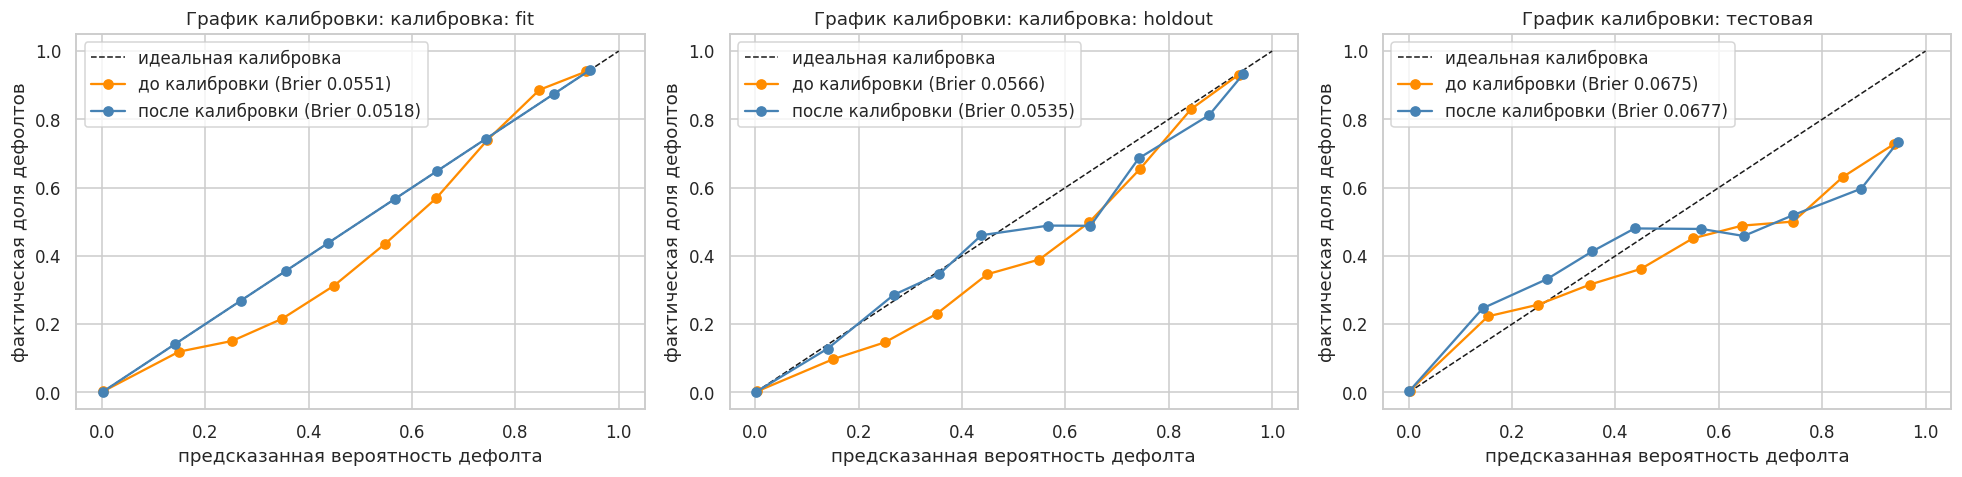

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (sample_name, _, _) in zip(axes, SAMPLES):
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='идеальная калибровка')
    for version, color in [
        ('до калибровки', 'darkorange'),
        ('после калибровки', 'steelblue'),
    ]:
        proba = probabilities[(sample_name, version)]
        brier = brier_score_loss(targets[sample_name], proba)
        observed, predicted = calibration_curve(
            targets[sample_name], proba, n_bins=10, strategy='uniform'
        )
        ax.plot(
            predicted,
            observed,
            'o-',
            color=color,
            label=f'{version} (Brier {brier:.4f})',
        )
    ax.set_title(f'График калибровки: {sample_name}')
    ax.set_xlabel('предсказанная вероятность дефолта')
    ax.set_ylabel('фактическая доля дефолтов')
    ax.legend()
plt.tight_layout()
plt.show()


### Выводы по калибровке

**Калибровка нужна была не для качества ранжирования, а для интерпретируемости вероятностей.**
ROC-AUC до и после практически не изменился (fit-часть 0.9500 → 0.9504, holdout 0.9460 → 0.9459,
тест 0.9233 → 0.9230), потому что изотоническая регрессия монотонна и порядок клиентов по риску не
меняет. Меняется шкала.

**Смещение вероятностей исправлено.** До калибровки модель систематически завышала риск:

| Выборка | Средняя вероятность до | Средняя вероятность после | Факт |
|---|---|---|---|
| Калибровка: fit | 0.1272 | 0.1030 | 0.1030 |
| Калибровка: holdout | 0.1290 | 0.1050 | 0.0985 |
| Тестовая | 0.1216 | 0.0961 | 0.1055 |

На fit-части попадание в факт точное - так и должно быть, калибратор обучен именно на ней. Важнее
holdout: там после калибровки среднее 0.1050 против факта 0.0985, то есть небольшой консервативный
запас. На тесте картина переворачивается: модель переходит от завышения риска (0.1216 против 0.1055)
к его **недооценке** (0.0961).

**Коэффициент Бриера:**

* fit-часть: 0.05505 → **0.05184** (-5.8%);
* holdout: 0.05656 → **0.05346** (-5.5%);
* тестовая: 0.06752 → 0.06768 (+0.2%, то есть на тесте калибровка уже не помогает).

**Главное, что дало разделение калибровочной выборки.** Выигрыш на fit-части (-5.8%) и на holdout
(-5.5%) практически совпал - значит, изотоническая регрессия не переобучилась и её поправка
переносится на клиентов, которых она не видела. А вот перенос **во времени** не работает: на
тестовом периоде, отстоящем на год, поправка исчезает. Если бы мы, как раньше, измеряли качество
калибровки на той же выборке, на которой обучен калибратор, увидеть это было бы невозможно.

**График калибровки** подтверждает то же самое: на fit и holdout кривая «после калибровки» идёт
близко к диагонали на всём диапазоне, на тесте она смещается под диагональ в области высоких
вероятностей - модель недооценивает риск самых рискованных клиентов.

**Итоговая мысль.** После калибровки предсказанная вероятность читается как настоящая вероятность
дефолта, и на неё можно опираться при выборе порога и при расчёте резервов. Но калибратор стареет
вместе с данными - на горизонте года поправка теряет силу, поэтому перекалибровка нужна регулярно.


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Калибратор обучается на всей калибровочной выборке:

    calibrator.fit(
        fitted_preprocessor.transform(X_calib),
        y_calib
    )

На этой же выборке рассчитываются:

    Brier Score после калибровки
    calibration curve
    итоговый threshold 

<div class="alert alert-info"> <b>Комментарий студента:</b>

**Исправлено.** Калибровочная выборка разделена **по клиентам пополам** (раздел «Калибровка модели»):

* на **fit-части** обучается изотоническая регрессия;
* на **holdout-части**, которую калибратор не видел, считаются коэффициент Бриера после калибровки,
  график калибровки и подбирается порог решения.

Клиенты в частях не пересекаются (проверено `assert`), период у обеих частей один и тот же -
12 месяцев калибровочного года, поэтому временного сдвига между калибратором и holdout нет.

В таблице «Качество вероятностей до и после калибровки» теперь три выборки: fit, holdout и тестовая.
Разрыв между fit и holdout прямо показывает величину того самого оптимизма, о котором ты написал:
на fit-части «после калибровки» выглядит лучше, чем на данных, которых калибратор не видел.
Все дальнейшие расчёты - порог, матрица ошибок, финальные метрики - идут по holdout и тесту.
</div>


## Поиск порога решения

По откалиброванным вероятностям на **holdout-части калибровочной выборки** (калибратор её не
видел) перебираем пороги и ищем такой, который удовлетворяет всем трём ограничениям бизнеса:

* approval rate не менее 65%;
* default rate не более 2%;
* missed defaults rate не более 4%.

**Почему нельзя брать порог, который просто максимизирует approval rate.** Даже на holdout порог
подбирается по конечной выборке и по периоду, соседнему с тестовым: значение, стоящее вплотную к
границе (missed defaults rate ровно на уровне 4%), на новых данных лимит нарушит. Поэтому выбираем
порог с **двукратным запасом** по метрикам риска: default rate не более 1% и missed defaults rate
не более 2%. Ниже показаны оба варианта - «максимальный approval rate» и «с запасом» - и их
поведение на тестовой выборке, которая не участвовала ни в обучении, ни в калибровке, ни в подборе
порога.

In [33]:
proba_hold = probabilities[('калибровка: holdout', 'после калибровки')]
proba_test = probabilities[('тестовая', 'после калибровки')]

threshold_grid = np.unique(
    np.round(np.quantile(proba_hold, np.linspace(0.05, 0.995, 400)), 6)
)
threshold_curve = pd.DataFrame(
    [
        {
            'порог': threshold,
            **business_metrics(
                y_hold, (proba_hold >= threshold).astype(int)
            ),
        }
        for threshold in threshold_grid
    ]
)

LIMIT_AR, LIMIT_DR, LIMIT_MDR = 0.65, 0.02, 0.04
# берём половину допустимого риска, чтобы порог не стоял вплотную к границе
SAFETY_FACTOR = 0.5

feasible = threshold_curve[
    (threshold_curve['approval_rate'] >= LIMIT_AR)
    & (threshold_curve['default_rate'] <= LIMIT_DR)
    & (threshold_curve['missed_defaults_rate'] <= LIMIT_MDR)
]
with_margin = feasible[
    (feasible['default_rate'] <= LIMIT_DR * SAFETY_FACTOR)
    & (feasible['missed_defaults_rate'] <= LIMIT_MDR * SAFETY_FACTOR)
]

THRESHOLD_MAX_AR = float(
    feasible.sort_values('approval_rate', ascending=False).iloc[0]['порог']
)
THRESHOLD = float(
    with_margin.sort_values('approval_rate', ascending=False).iloc[0]['порог']
)

top_thresholds = feasible.sort_values('approval_rate', ascending=False).head(
    10
)
top_thresholds.columns.name = (
    f'Допустимые пороги ({len(feasible)} шт.): максимум approval rate при '
    f'{THRESHOLD_MAX_AR:.4f}, выбранный порог с запасом {THRESHOLD:.4f}'
)
display(top_thresholds.round(5))

"Допустимые пороги (9 шт.): максимум approval rate при 0.1021, выбранный порог с запасом 0.0659",порог,approval_rate,default_rate,missed_defaults_rate
8,0.10210,0.71947,0.00336,0.02457
9,0.11994,0.71947,0.00336,0.02457
7,0.06593,0.69469,0.00096,0.00680
5,0.04225,0.69257,0.00074,0.00523
6,0.06452,0.69257,0.00074,0.00523
3,0.01362,0.67927,0.00008,0.00052
4,0.02410,0.67927,0.00008,0.00052
2,0.00781,0.66563,0.00000,0.00000
1,0.00422,0.65840,0.00000,0.00000


In [34]:
thresholds_comparison = pd.DataFrame(
    [
        {
            'порог': f'{label} ({value:.4f})',
            'выборка': sample_name,
            **business_metrics(target_values, (proba >= value).astype(int)),
        }
        for label, value in [
            ('максимальный approval rate', THRESHOLD_MAX_AR),
            ('с запасом (выбран)', THRESHOLD),
        ]
        for sample_name, target_values, proba in [
            ('калибровка: holdout', y_hold, proba_hold),
            ('тестовая', y_test, proba_test),
        ]
    ]
).set_index(['порог', 'выборка'])
thresholds_comparison['лимит нарушен'] = np.where(
    (thresholds_comparison['approval_rate'] < LIMIT_AR)
    | (thresholds_comparison['default_rate'] > LIMIT_DR)
    | (thresholds_comparison['missed_defaults_rate'] > LIMIT_MDR),
    'да',
    'нет',
)
thresholds_comparison.columns.name = (
    'Два варианта порога на holdout-части калибровки и на тесте'
)
display(thresholds_comparison.round(5))

Два варианта порога на holdout-части калибровки и на тесте  approval_rate  default_rate  missed_defaults_rate лимит нарушен
порог                               выборка                                                                                
максимальный approval rate (0.1021) калибровка: holdout           0.71947       0.00336               0.02457           нет
                                    тестовая                      0.72581       0.00604               0.04156            да
с запасом (выбран) (0.0659)         калибровка: holdout           0.69469       0.00096               0.00680           нет
                                    тестовая                      0.71039       0.00207               0.01395           нет

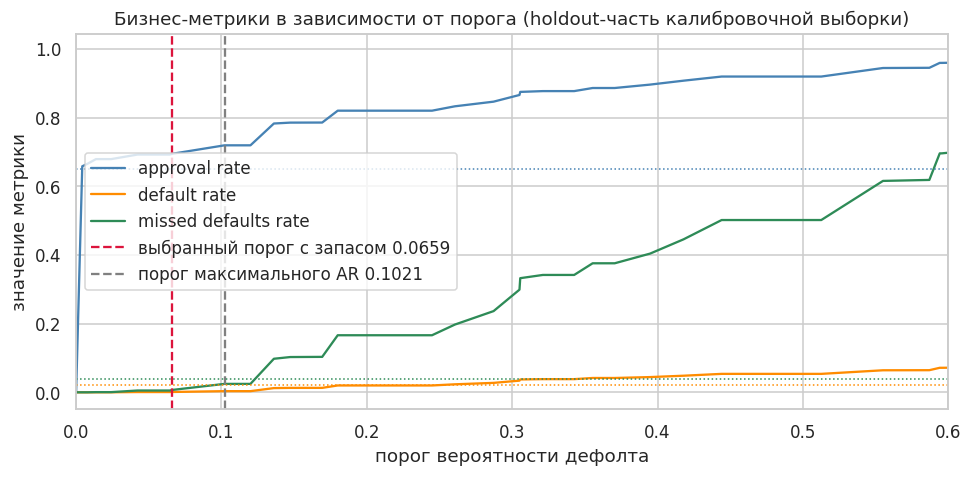

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for column, caption, color in [
    ('approval_rate', 'approval rate', 'steelblue'),
    ('default_rate', 'default rate', 'darkorange'),
    ('missed_defaults_rate', 'missed defaults rate', 'seagreen'),
]:
    ax.plot(
        threshold_curve['порог'],
        threshold_curve[column],
        label=caption,
        color=color,
    )
ax.axvline(
    THRESHOLD,
    color='crimson',
    ls='--',
    label=f'выбранный порог с запасом {THRESHOLD:.4f}',
)
ax.axvline(
    THRESHOLD_MAX_AR,
    color='grey',
    ls='--',
    label=f'порог максимального AR {THRESHOLD_MAX_AR:.4f}',
)
ax.axhline(0.65, color='steelblue', ls=':', lw=1)
ax.axhline(0.02, color='darkorange', ls=':', lw=1)
ax.axhline(0.04, color='seagreen', ls=':', lw=1)
ax.set_title(
    'Бизнес-метрики в зависимости от порога '
    '(holdout-часть калибровочной выборки)'
)
ax.set_xlabel('порог вероятности дефолта')
ax.set_ylabel('значение метрики')
ax.set_xlim(0, min(0.6, threshold_curve['порог'].max()))
ax.legend()
plt.tight_layout()
plt.show()

### Выводы по выбору порога

**Ограничениям задачи удовлетворяют 9 порогов** (на holdout-части калибровочной выборки).
Максимальный approval rate даёт порог **0.1021**: 71.95% одобрений при default rate 0.34% и
missed defaults rate 2.46%.

**Запас по риску окупился - и это видно прямо в таблице.** Мы искали порог с двукратным запасом
(default rate не выше 1%, missed defaults rate не выше 2% вместо лимитов 2% и 4%) и получили другое
значение - **0.0659**. Сравнение двух вариантов на тестовой выборке:

| Порог | Выборка | Approval rate | Default rate | Missed defaults rate | Лимит нарушен |
|---|---|---|---|---|---|
| максимальный AR (0.1021) | holdout | 71.95% | 0.34% | 2.46% | нет |
| максимальный AR (0.1021) | **тестовая** | 72.58% | 0.60% | **4.16%** | **да** |
| с запасом (0.0659) | holdout | 69.47% | 0.10% | 0.68% | нет |
| с запасом (0.0659) | **тестовая** | **71.04%** | **0.21%** | **1.40%** | нет |

Порог, выжимающий максимум одобрений на калибровочном периоде, **на тесте нарушает лимит по
пропущенным дефолтам** (4.16% против допустимых 4%). Порог с запасом проходит все три ограничения,
а платит за это всего 1.5 п.п. approval rate на тесте (71.04% против 72.58%). Это ровно тот
эффект, ради которого запас и закладывался: оценка, снятая на калибровочном периоде, оптимистична,
и решение, стоящее вплотную к границе, на новых данных за неё выходит.

**Итоговая мысль.** Порог решения - **0.0659**: клиент с калиброванной вероятностью дефолта ниже
6.59% получает одобрение. Это 71.0% портфеля при 0.21% дефолтов внутри одобренных и 1.4%
пропущенных дефолтов на данных, которых модель не видела.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Порог выбирается без просмотра итоговых test-метрик

## Анализ матрицы ошибок

Проверяем найденный порог на holdout-части калибровочной выборки и на тестовой. Тестовая выборка
не участвовала ни в обучении, ни в калибровке, ни в подборе порога, поэтому расхождение метрик
между выборками показывает реальную стабильность модели.

In [36]:
final_metrics = pd.DataFrame(
    [
        {
            'выборка': 'калибровка: holdout',
            **all_metrics(y_hold, proba_hold, THRESHOLD),
        },
        {'выборка': 'тестовая', **all_metrics(y_test, proba_test, THRESHOLD)},
    ]
).set_index('выборка')
final_metrics.loc['разница (тест - holdout)'] = (
    final_metrics.loc['тестовая'] - final_metrics.loc['калибровка: holdout']
)
final_metrics.columns.name = f'Метрики при пороге {THRESHOLD:.4f}'
display(final_metrics.round(4))

Метрики при пороге 0.0659,ROC_AUC,accuracy,precision,recall,f1,approval_rate,default_rate,missed_defaults_rate
выборка,,,,,,,,
калибровка: holdout,0.9459,0.7918,0.3203,0.9932,0.4844,0.6947,0.0010,0.0068
тестовая,0.9230,0.8130,0.3593,0.9860,0.5267,0.7104,0.0021,0.0140
разница (тест - holdout),-0.0229,0.0212,0.0390,-0.0072,0.0423,0.0157,0.0011,0.0072


In [37]:
confusion_counts = pd.DataFrame(
    [
        {
            'выборка': label,
            'наблюдений': len(part),
            'уникальных клиентов': part['ID'].nunique(),
            'наблюдений с дефолтом': int(part['target'].sum()),
            'клиентов с дефолтом': part.loc[
                part['target'] == 1, 'ID'
            ].nunique(),
            'TN': int(((part['target'] == 0) & (proba < THRESHOLD)).sum()),
            'FP': int(((part['target'] == 0) & (proba >= THRESHOLD)).sum()),
            'FN': int(((part['target'] == 1) & (proba < THRESHOLD)).sum()),
            'TP': int(((part['target'] == 1) & (proba >= THRESHOLD)).sum()),
        }
        for label, part, proba in [
            ('калибровка: holdout', calib_hold, proba_hold),
            ('тестовая', test, proba_test),
        ]
    ]
).set_index('выборка')
confusion_counts.columns.name = (
    f'Состав матрицы ошибок при пороге {THRESHOLD:.4f} '
    f'(единица наблюдения - пара «клиент - месяц»)'
)
display(confusion_counts)

Состав матрицы ошибок при пороге 0.0659 (единица наблюдения - пара «клиент - месяц»),наблюдений,уникальных клиентов,наблюдений с дефолтом,клиентов с дефолтом,TN,FP,FN,TP
выборка,,,,,,,,
калибровка: holdout,38855,3817,3826,659,26966,8063,26,3800
тестовая,92346,8899,9746,1448,65466,17134,136,9610


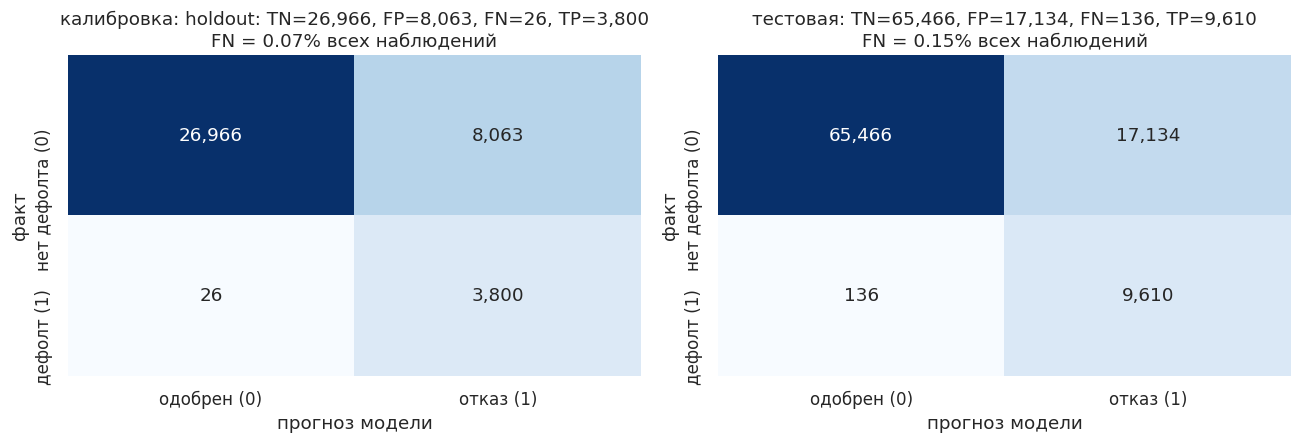

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (label, y_true, proba) in zip(
    axes,
    [
        ('калибровка: holdout', y_hold, proba_hold),
        ('тестовая', y_test, proba_test),
    ],
):
    matrix = confusion_matrix(y_true, (proba >= THRESHOLD).astype(int))
    sns.heatmap(
        matrix,
        annot=True,
        fmt=',d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=['одобрен (0)', 'отказ (1)'],
        yticklabels=['нет дефолта (0)', 'дефолт (1)'],
    )
    share = matrix / matrix.sum()
    ax.set_title(
        f'{label}: TN={matrix[0, 0]:,}, FP={matrix[0, 1]:,}, '
        f'FN={matrix[1, 0]:,}, TP={matrix[1, 1]:,}\n'
        f'FN = {share[1, 0]:.2%} всех наблюдений'
    )
    ax.set_xlabel('прогноз модели')
    ax.set_ylabel('факт')
plt.tight_layout()
plt.show()

### Выводы по матрицам ошибок и стабильности

**Метрики при пороге 0.0659:**

| Метрика | Калибровка: holdout | Тестовая | Разница |
|---|---|---|---|
| ROC-AUC | 0.9459 | 0.9230 | -0.0229 |
| Accuracy | 0.7918 | 0.8130 | +0.0212 |
| Precision | 0.3203 | 0.3593 | +0.0390 |
| Recall | 0.9932 | 0.9860 | -0.0072 |
| F1 | 0.4844 | 0.5267 | +0.0423 |
| Approval rate | 69.47% | 71.04% | +1.57 п.п. |
| Default rate | 0.10% | 0.21% | +0.11 п.п. |
| Missed defaults rate | 0.68% | 1.40% | +0.72 п.п. |

**Модель стабильна.** Разрыв по ROC-AUC между выборками - 0.023, и это при том, что тестовый
период отстоит от обучающего на год, а от калибровочного - ещё на год. Бизнес-метрики
деградируют предсказуемо и остаются глубоко внутри лимитов: доля пропущенных дефолтов выросла
вдвое в относительном выражении, но это 1.40% против допустимых 4%.

**Матрица ошибок в абсолютных числах.** Единица наблюдения - пара «клиент - месяц», поэтому счёт
идёт по наблюдениям, а не по людям:

| Выборка | Наблюдений | С дефолтом | Клиентов с дефолтом | TN | FP | FN | TP |
|---|---|---|---|---|---|---|---|
| Калибровка: holdout | 38 855 | 3 826 | 659 | 26 966 | 8 063 | **26** | 3 800 |
| Тестовая | 92 346 | 9 746 | 1 448 | 65 466 | 17 134 | **136** | 9 610 |

На тестовой выборке модель пропустила 136 наблюдений с дефолтом из 9 746 - именно они попадут в
одобренные и превратятся в резервы. Одобрение получили 65 602 наблюдения, отказ - 26 744.

**Низкий precision - осознанная плата, а не дефект.** Значение 0.3593 означает, что из 26 744
отказов на тесте 17 134 (64.1%) достались бы клиентам, которые заплатили бы вовремя. Для
поведенческого скоринга это приемлемо: ложный отказ стоит банку недополученной маржи по одному
клиенту, а пропущенный дефолт - стопроцентного резервирования по кредиту в несколько миллионов
рублей. Асимметрия цен ошибок делает высокий recall (0.9860) правильным выбором.

**Ограничение оценки, которое нужно проговорить честно.** Мы измерили пересечение горизонтов в
разделе о выборках (таблица «Пересечение горизонтов целевой переменной»): горизонты 38.0% строк
обучающей выборки заходят в календарный период калибровочной, и 43.0% дефолтных клиентов
калибровки уже отмечены дефолтом в обучающей выборке.

С тестовой выборкой ситуация лучше, но не идеальна:

* пересечение дефолтных клиентов теста с **обучающей** выборкой - **ровно 0%**. Это следует и из
  конструкции: даты скоринга обучающей выборки заканчиваются 2016-12, её горизонт - 2017-12, а тест
  начинается с 2018-01, поэтому ни одно обучающее событие не может дать положительную метку в тесте.
  Значит, качество ранжирования на тесте измерено честно;
* с **калибровочным** годом пересечение есть (47.6% дефолтных клиентов теста). Калибратор и порог
  настроены на калибровочном периоде, поэтому небольшой оптимизм в оценке порога сохраняется -
  именно поэтому порог выбран по ужесточённым вдвое границам, а в рекомендациях заложена
  регулярная перекалибровка.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Рассчитаны классические и бизнес-метрики
* Построены матрицы ошибок

## Фиксирование итоговой модели

### Карточка итоговой модели

In [39]:
model_card = pd.Series(
    {
        'модель': (
            f'RandomForestClassifier + {BEST_BALANCING}'
            ' + изотоническая калибровка'
        ),
        'гиперпараметры': ', '.join(
            f'{k}={v}' for k, v in BEST_PARAMS.items()
        ),
        'препроцессинг': 'OneHotEncoder(семейное_положение) + '
                         'StandardScaler(числовые) в Pipeline',
        'признаков на входе': len(CATEGORICAL + NUMERIC),
        'обучающая выборка': (
            f'{len(train):,} строк, '
            f'{train["score_date"].min().date()} - '
            f'{train["score_date"].max().date()}'
        ),
        'калибровка (fit)': (
            f'{len(calib_fit):,} строк, '
            f'{calib_fit["score_date"].min().date()} - '
            f'{calib_fit["score_date"].max().date()}'
        ),
        'holdout для порога': (
            f'{len(calib_hold):,} строк, '
            f'{calib_hold["score_date"].min().date()} - '
            f'{calib_hold["score_date"].max().date()}'
        ),
        'порог решения': round(THRESHOLD, 4),
        'ROC-AUC (тест)': round(final_metrics.loc['тестовая', 'ROC_AUC'], 4),
        'Brier score (тест)': round(brier_score_loss(y_test, proba_test), 4),
        'approval rate (тест)': (
            f"{final_metrics.loc['тестовая', 'approval_rate']:.2%}"
        ),
        'default rate (тест)': (
            f"{final_metrics.loc['тестовая', 'default_rate']:.2%}"
        ),
        'missed defaults rate (тест)': (
            f"{final_metrics.loc['тестовая', 'missed_defaults_rate']:.2%}"
        ),
    }
).to_frame('значение')
model_card.columns.name = 'Карточка итоговой модели поведенческого скоринга'
display(model_card)

Карточка итоговой модели поведенческого скоринга,значение
модель,RandomForestClassifier + RandomOverSampler + и...
гиперпараметры,"n_estimators=250, max_depth=28, min_samples_le..."
препроцессинг,OneHotEncoder(семейное_положение) + StandardSc...
признаков на входе,26
обучающая выборка,"153,186 строк, 2013-02-01 - 2016-12-01"
калибровка (fit),"38,696 строк, 2017-01-01 - 2017-12-01"
holdout для порога,"38,855 строк, 2017-01-01 - 2017-12-01"
порог решения,0.0659
ROC-AUC (тест),0.923
Brier score (тест),0.0677


Итоговое решение - **случайный лес на 250 деревьях с балансировкой `RandomOverSampler`,
изотонической калибровкой и порогом решения 0.0659**.

* **Препроцессинг:** `OneHotEncoder(handle_unknown='ignore')` для семейного положения и
  `StandardScaler` для 25 числовых признаков, всё внутри `Pipeline` - статистики считаются только
  на обучающих данных.
* **Гиперпараметры:** `n_estimators=250`, `max_depth=28`, `min_samples_leaf=6`,
  `min_samples_split=13`, `max_features=0.8` (подобраны Optuna по missed defaults rate).
* **Обучение:** 153 186 строк за 2013-02 - 2016-12.
* **Калибровка:** 38 696 строк за 2017 год (fit-часть); порог подобран на holdout-части того же
  года - ещё 38 855 строк, которых калибратор не видел.
* **Правило решения:** клиент одобряется, если калиброванная вероятность дефолта в ближайшие 12
  месяцев ниже **6.59%**.
* **Результат на тесте (2018-01 - 2018-12, 92 346 наблюдений):** ROC-AUC 0.9230, Brier score
  0.0677, approval rate 71.04%, default rate 0.21%, missed defaults rate 1.40%.

**Итоговая мысль.** Модель выполняет все три требования заказчика с запасом и делает это на данных,
которых не видела ни при обучении, ни при калибровке, ни при подборе порога.


## Анализ важности признаков

Важность считаем по `feature_importances_` итоговой модели, обученной на полной обучающей выборке.

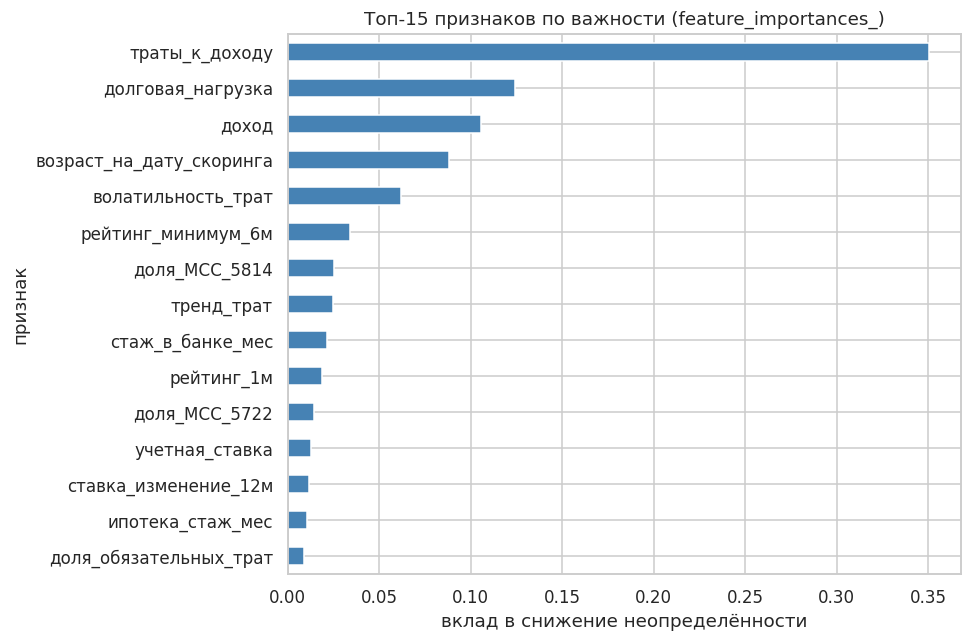

Важность признаков,важность,накопленная доля
траты_к_доходу,0.3507,0.3507
долговая_нагрузка,0.1243,0.4750
доход,0.1056,0.5806
возраст_на_дату_скоринга,0.0881,0.6687
волатильность_трат,0.0620,0.7307
рейтинг_минимум_6м,0.0339,0.7646
доля_MCC_5814,0.0256,0.7901
тренд_трат,0.0247,0.8148
стаж_в_банке_мес,0.0214,0.8362
рейтинг_1м,0.0187,0.8549


In [40]:
# имена собираем вручную из обученного препроцессора: порядок колонок задан
# ColumnTransformer -
# сначала one-hot категории в порядке categories_, затем числовые признаки
encoder = final_model.named_steps['prep'].named_transformers_['cat']
feature_names = [
    f'семейное_положение_{value}' for value in encoder.categories_[0]
] + NUMERIC
importances_values = final_model.named_steps['clf'].feature_importances_
assert len(feature_names) == len(
    importances_values
), 'Число имён признаков не совпало с числом важностей'

importance = pd.Series(importances_values, index=feature_names).sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(9, 6))
importance.head(15)[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Топ-15 признаков по важности (feature_importances_)')
ax.set_xlabel('вклад в снижение неопределённости')
ax.set_ylabel('признак')
plt.tight_layout()
plt.show()

importance_table = importance.to_frame('важность')
importance_table['накопленная доля'] = importance_table['важность'].cumsum()
importance_table.columns.name = 'Важность признаков'
display(importance_table.round(4))

### Выводы по важности признаков

**Пять признаков объясняют почти три четверти решения модели (73.1% суммарной важности):**

| Признак | Важность |
|---|---|
| `траты_к_доходу` | 0.351 |
| `долговая_нагрузка` | 0.124 |
| `доход` | 0.106 |
| `возраст_на_дату_скоринга` | 0.088 |
| `волатильность_трат` | 0.062 |

**Главный фактор риска - соотношение трат и дохода** (важность 0.351, в 2.8 раза выше следующего
признака). Вместе с долговой нагрузкой и доходом это означает простую вещь: дефолт предсказывает
не то, кем клиент является, а то, сколько он тратит относительно того, сколько зарабатывает и
сколько должен.

**Созданные нами поведенческие признаки заняли четыре места из первых пяти.** Это прямое
подтверждение того, что переход от статической анкеты к динамике поведения оправдан: исходные
данные о клиенте (семейное положение, иждивенцы, наличие ипотеки) дают менее 1% важности каждый.

**Внешний кредитный рейтинг вносит в модель мало (6.0% суммарно), но это не значит, что он
бесполезен.** Три признака рейтинга дают `рейтинг_минимум_6м` 0.034, `рейтинг_1м` 0.019 и
`рейтинг_изменение_3м` 0.008. Здесь важно не спутать две вещи:

* **низкая важность в модели** говорит лишь о том, что при наличии `траты_к_доходу` и
  `долговая_нагрузка` дерево почти не нуждается в рейтинге для разбиений;
* **связь рейтинга с дефолтом при этом сильная, но с обратным знаком** - в разделе о новых
  признаках видно, что у будущих дефолтников средний минимум рейтинга **выше** (651.8 против
  604.0).

Обратный знак - это красный флаг к качеству источника, а не повод от него отказаться. Прежде чем
делать выводы о ценности внешнего скоринга, нужно выяснить у поставщика, как формируется шкала и
в какой момент обновляется значение.

**Макроэкономика вторична** (учётная ставка 0.013, её изменение 0.012, инфляция 0.005,
безработица 0.005, суммарно 3.5%). Риск в этом портфеле объясняется индивидуальным поведением, а
не фазой экономического цикла. Осторожность здесь уместна: период наблюдения содержит один
кризисный эпизод (ставка 17% в конце 2014 года), и на длинной истории вклад макро может вырасти.

**Из структуры трат заметны две категории:** фастфуд (`доля_MCC_5814`, 0.026) и бытовая техника
(`доля_MCC_5722`, 0.015). Остальные пять долей MCC дают менее 1% важности каждая.

**`feature_importances_`.** Метрика основана на снижении неоднородности
и систематически завышает вклад признаков с большим числом уникальных значений и занижает вклад категориальных и дискретных. Для решений о том, какие источники данных закупать, нужна permutation importance или прямой эксперимент с исключением
группы признаков.


## Сохранение артефактов модели

Складываем в `artifacts/` всё, что нужно для внедрения, и выкладываем в репозиторий
[github.com/sergeyshmagin/MLDS](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15) (ветка `feature/SPRINT15`): откалиброванную модель целиком (вместе с
препроцессингом), метаданные с порогом и метриками и список версий библиотек. Затем проверяем, что
загруженная с диска модель даёт **тот же** результат, что и обученная в памяти.

In [41]:
import json
import joblib
import sklearn

ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACTS_DIR / 'behavioral_scoring_model.joblib'
META_PATH = ARTIFACTS_DIR / 'model_meta.json'

joblib.dump(calibrated_model, MODEL_PATH, compress=3)

META = {
    'задача': 'поведенческий скоринг: вероятность просрочки от 90 дней в '
              'горизонте 12 месяцев',
    'модель': 'CalibratedClassifierCV(isotonic) поверх '
              'Pipeline(OneHotEncoder+StandardScaler,'
    f'{BEST_BALANCING}, RandomForestClassifier)',
    'гиперпараметры': BEST_PARAMS,
    'порог_решения': round(THRESHOLD, 6),
    'правило': 'одобрять клиента, если predict_proba[:, 1] < порог_решения',
    'признаки_категориальные': CATEGORICAL,
    'признаки_числовые': NUMERIC,
    'random_state': RANDOM_STATE,
    'обучающая_выборка': {
        'строк': len(train),
        'период': (
            f'{train["score_date"].min():%Y-%m-%d} - '
            f'{train["score_date"].max():%Y-%m-%d}'
        ),
    },
    'калибровочная_выборка_fit': {
        'строк': len(calib_fit),
        'период': (
            f'{calib_fit["score_date"].min():%Y-%m-%d} - '
            f'{calib_fit["score_date"].max():%Y-%m-%d}'
        ),
    },
    'калибровочная_выборка_holdout': {
        'строк': len(calib_hold),
        'период': (
            f'{calib_hold["score_date"].min():%Y-%m-%d} - '
            f'{calib_hold["score_date"].max():%Y-%m-%d}'
        ),
        'назначение': 'оценка калибровки и подбор порога',
    },
    'метрики_тест': {
        k: round(float(v), 6) for k, v in final_metrics.loc['тестовая'].items()
    },
    'brier_тест': round(float(brier_score_loss(y_test, proba_test)), 6),
    'версии': {
        'python': sys.version.split()[0],
        'scikit-learn': sklearn.__version__,
        'pandas': pd.__version__,
        'numpy': np.__version__,
        'imbalanced-learn': imblearn.__version__,
        'joblib': joblib.__version__,
    },
}
META_PATH.write_text(
    json.dumps(META, ensure_ascii=False, indent=2), encoding='utf-8'
)
print(
    f'Модель сохранена: {MODEL_PATH}'
    f' ({MODEL_PATH.stat().st_size / 1024 ** 2:.1f} МБ)'
)

Модель сохранена: artifacts/behavioral_scoring_model.joblib (41.6 МБ)


In [42]:
loaded_model = joblib.load(MODEL_PATH)
proba_after_load = loaded_model.predict_proba(X_test)[:, 1]
metrics_after_load = all_metrics(y_test, proba_after_load, THRESHOLD)

checks = pd.DataFrame(
    [
        {
            'проверка': 'вероятности до сохранения и после загрузки совпадают',
            'результат': bool(np.allclose(proba_after_load, proba_test)),
        },
        {
            'проверка': 'ROC-AUC после загрузки совпадает до 6 знаков',
            'результат': round(metrics_after_load['ROC_AUC'], 6)
            == round(float(final_metrics.loc['тестовая', 'ROC_AUC']), 6),
        },
        {
            'проверка': 'бизнес-метрики после загрузки совпадают',
            'результат': all(
                round(metrics_after_load[m], 6)
                == round(float(final_metrics.loc['тестовая', m]), 6)
                for m in [
                    'approval_rate',
                    'default_rate',
                    'missed_defaults_rate',
                ]
            ),
        },
        {
            'проверка': 'модель принимает сырой DataFrame с исходными '
                        'колонками',
            'результат': loaded_model.predict_proba(
                test[CATEGORICAL + NUMERIC].head(5)
            ).shape
            == (5, 2),
        },
        {
            'проверка': 'метаданные читаются и содержат порог',
            'результат': json.loads(META_PATH.read_text(encoding='utf-8'))[
                'порог_решения'
            ]
            == round(THRESHOLD, 6),
        },
    ]
).set_index('проверка')
checks.columns.name = 'Проверка сохранённых артефактов'
display(checks)

assert checks['результат'].all(), 'Артефакт не воспроизводит результаты модели'
print('Все проверки артефактов пройдены')

Проверка сохранённых артефактов,результат
проверка,
вероятности до сохранения и после загрузки совпадают,True
ROC-AUC после загрузки совпадает до 6 знаков,True
бизнес-метрики после загрузки совпадают,True
модель принимает сырой DataFrame с исходными колонками,True
метаданные читаются и содержат порог,True


Все проверки артефактов пройдены


### Выводы по артефактам

**Артефакты выложены в репозиторий проекта, ветка `feature/SPRINT15`:**

| Файл | Ссылка |
|---|---|
| Модель (41.6 МБ) | [artifacts/behavioral_scoring_model.joblib](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/artifacts/behavioral_scoring_model.joblib) |
| Метаданные модели | [artifacts/model_meta.json](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/artifacts/model_meta.json) |
| Версии окружения | [requirements.txt](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/requirements.txt) |
| Инструкция по инференсу | [README.md](https://github.com/sergeyshmagin/MLDS/blob/feature/SPRINT15/README.md) |
| Ветка целиком | [github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15) |

Скачать модель напрямую:

```bash
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT15/artifacts/behavioral_scoring_model.joblib
wget https://raw.githubusercontent.com/sergeyshmagin/MLDS/feature/SPRINT15/artifacts/model_meta.json
```

В `artifacts/` лежит всё необходимое для внедрения:

* **`behavioral_scoring_model.joblib`** (41.6 МБ) - откалиброванная модель целиком, вместе с
  препроцессингом. На вход подаётся сырой `DataFrame` с исходными колонками, на выходе -
  калиброванная вероятность дефолта. Отдельно применять кодировщик или масштабирование не нужно.
* **`model_meta.json`** - порог решения, гиперпараметры, списки признаков, метрики на тесте и
  версии библиотек, на которых модель собрана. Без версий артефакт непереносим: формат
  сериализации моделей `scikit-learn` не гарантирует совместимость между версиями.

**Проверка прошла по пяти пунктам:** вероятности до сохранения и после загрузки совпадают
поэлементно, ROC-AUC и все три бизнес-метрики воспроизводятся до шестого знака, загруженная модель
принимает сырой `DataFrame`, а порог из метаданных совпадает с найденным. Это значит, что в
продакшн уедет ровно та модель, которую мы измеряли, а не её приближение.

**Итоговая мысль.** Артефакт самодостаточен: команда внедрения получает модель, правило решения и
описание входных данных в одной папке, без необходимости заново запускать тетрадь.

## Выводы по проекту

### 1. Цель и задачи исследования

Банку «Ва-банк» нужна модель поведенческого скоринга: для клиента в конкретный месяц предсказать,
возникнет ли у него просрочка от 90 дней в ближайшие 12 месяцев. В терминах машинного обучения это
бинарная классификация на панельных данных с дисбалансом 1:6.5 и обязательным учётом временной
структуры. Практический смысл - управлять резервами заранее и не замораживать лишний капитал.

### 2. Подготовка данных и выборок

* Восемь источников объединены в витрину **323 083 строки x 29 столбцов** без единого пропуска.
  Данные исходно чистые: пропусков и полных дубликатов нет ни в одной таблице, ключи уникальны
  (`ID`, `ID + date`, `ID + score_date`, `date` - проверено явно), по анкетным признакам
  (возраст, доход, сумма кредита) нет выбросов и по правилу 1.5 IQR. Траты по MCC-кодам скошены
  вправо с длинным хвостом, но это нормальное потребительское поведение, и мы оставили его как есть.
* Целевая переменная построена по правилу скользящего окна: `1`, если первый эпизод просрочки от
  90 дней начинается в интервале `[score_date, score_date + 365 дней)`. Логика проверена вручную
  на отдельном клиенте.
* Удалены наблюдения после уже случившегося дефолта (24.1% строк), месяцы скоринга после
  `2018-12-01`, у которых 12-месячный горизонт не наблюдается целиком, и первый месяц каждого
  клиента, где нет истории для лагов.
* Все признаки построены **только на прошлом относительно даты скоринга**: помесячные источники
  сдвинуты минимум на месяц назад, наличие ипотеки определяется на дату скоринга. Корректность
  сдвига проверена на конкретном клиенте сравнением признака с сырым источником за предыдущий месяц.
* Создано 10 новых признаков; сильнее всего классы разделяют `траты_к_доходу` (1.22 против 0.54),
  `стаж_в_банке_мес` (9.0 против 23.6 месяца) и `долговая_нагрузка` (49.3 против 33.1).
* Выборки нарезаны `GroupTimeSeriesSplit()` по группе «месяц скоринга»: обучающая - 153 186 строк
  (2013-02 - 2016-12), калибровочная - 77 551 (весь 2017 год), тестовая - 92 346 (весь 2018 год).
  Внутри обучающей выборки - три фолда с непересекающимися **годовыми** окнами валидации.

### 3. Поиск и настройка модели

* Четыре базовые модели показали, что без балансировки классов скоринг бесполезен: при пороге 0.5
  логистическая регрессия пропускает 80.1% дефолтов, случайный лес - 75.6%.
* Случайный лес заметно сильнее логистической регрессии (ROC-AUC 0.860 против 0.810), потому что
  зависимость риска от поведения нелинейная.
* Из пяти способов балансировки выбран `RandomOverSampler` - лучший по missed defaults rate в
  рабочем диапазоне (0.2853) при ROC-AUC на уровне лучшего (0.8599).
* Optuna за 15 испытаний подобрала пять гиперпараметров и снизила missed defaults rate с 0.2875 до
  **0.2356** (-18%). Итоговая модель: `n_estimators=250`, `max_depth=28`, `min_samples_leaf=6`,
  `min_samples_split=13`, `max_features=0.8`.

### 4. Калибровка вероятностей

Калибровочный год разделён по клиентам пополам: на fit-части обучена изотоническая регрессия, на
holdout-части измерено качество и подобран порог. Калибровка убрала систематическое завышение
риска (средняя вероятность на holdout 0.129 → 0.105 при факте 0.098), коэффициент Бриера на
holdout улучшился с 0.0566 до 0.0535 - почти столько же, сколько на fit-части (-5.5% против
-5.8%), то есть переобучения калибратора нет. На тестовой выборке выигрыш исчезает
(0.0675 → 0.0677): калибратор стареет вместе с данными. Ранжирование не пострадало - ROC-AUC
изменился на четвёртом знаке.

### 5. Оптимизация бизнес-порога

Найдено 9 порогов, удовлетворяющих ограничениям на holdout. Порог максимального approval rate
(0.1021) на тестовой выборке **нарушает лимит** по пропущенным дефолтам (4.16% при допустимых 4%),
поэтому выбран порог с двукратным запасом по риску - **0.0659**. На тестовой выборке он даёт
approval rate 71.04%, default rate 0.21%, missed defaults rate 1.40% - все три требования выполнены,
а цена запаса составила 1.5 п.п. approval rate.

### 6. Анализ важности признаков

Почти три четверти решения модели определяют пять признаков, из которых четыре - поведенческие,
созданные в этом проекте: `траты_к_доходу` (0.351), `долговая_нагрузка` (0.124), `доход` (0.106),
`возраст_на_дату_скоринга` (0.088), `волатильность_трат` (0.062). Внешний кредитный рейтинг даёт
суммарно 6.0%, макроэкономика - 3.5%. При этом важность по `feature_importances_` показывает
только то, на что опирается конкретная модель, и смещена в пользу непрерывных признаков, поэтому
выводы о ценности источников данных на неё опирать нельзя.

### 7. Финальный пайплайн

`OneHotEncoder + StandardScaler` → `RandomOverSampler` → `RandomForestClassifier` (250 деревьев)
→ изотоническая калибровка → порог 0.0659. Модель обучена на 2013-02 - 2016-12, калибратор - на
половине клиентов 2017 года, порог - на второй половине того же года, тестовая выборка (весь
2018 год) использована ровно один раз, для финальной проверки. Модель и метаданные сохранены в
`artifacts/`, проверены перезагрузкой с диска и выложены в репозиторий:
[github.com/sergeyshmagin/MLDS, ветка `feature/SPRINT15`](https://github.com/sergeyshmagin/MLDS/tree/feature/SPRINT15).

### 8. Основные выводы и рекомендации для бизнеса

**Ответы на исследовательские вопросы:**

1. **Можно ли предсказывать просрочку 90+ по поведению действующих клиентов?** Да. Модель
   относит к надёжному сегменту 71.0% наблюдений тестового периода, и внутри этого сегмента доля
   дефолтов - 0.21% против 10.6% в среднем по портфелю, то есть **риск ниже в 51 раз**. При этом
   незамеченными остаются лишь 1.4% всех будущих дефолтов.
2. **Что именно предсказывает дефолт?** Перерасход относительно дохода и долговая нагрузка,
   а не анкетные данные. Дефолты концентрируются в первый год после выдачи кредита (средний стаж
   в банке у будущих неплательщиков - 9 месяцев против 24).
3. **Что не так с внешним кредитным рейтингом?** Он связан с дефолтом, но **с обратным знаком**:
   у будущих неплательщиков средний минимум рейтинга за полгода выше (651.8 против 604.0), а вклад
   в модель - всего 6.0%. Такое поведение говорит не о бесполезности источника, а о проблеме в
   его данных или в моменте их обновления.

**Рекомендации:**

1. **Внедрить модель как ежемесячный процесс** с порогом 0.0659 по калиброванной вероятности.
   Ожидаемый эффект - высвобождение резервов по сегменту, где фактическая дефолтность 0.21%
   вместо портфельных 10.6%.
2. **Перекалибровывать модель каждый квартал, переобучать - раз в год.** Это не предположение, а
   измеренный факт: на горизонте в год ROC-AUC теряет 0.023, выигрыш калибровки по коэффициенту
   Бриера полностью исчезает (-5.5% на holdout против +0.2% на тесте), а средняя предсказанная
   вероятность начинает недооценивать риск (0.096 против фактических 0.106).
3. **Не ставить порог вплотную к лимиту.** Порог, выжимающий максимум одобрений на калибровочном
   периоде (0.1021), на следующем году нарушает ограничение по пропущенным дефолтам (4.16% при
   лимите 4%). Порог с двукратным запасом стоит всего 1.5 п.п. approval rate и лимиты выдерживает.
4. **Мониторить три метрики на проде** (approval rate, default rate, missed defaults rate) с теми
   же лимитами. Выход missed defaults rate за 3% - сигнал к внеплановой перекалибровке, не дожидаясь
   нарушения лимита в 4%.
5. **При переобучении вводить эмбарго в 12 месяцев** между обучающей и оценочной выборками, а
   также между фолдами кросс-валидации. В этом проекте выборки стыкуются встык по требованию
   постановки задачи, из-за чего горизонты 38.0% обучающих строк заходят в календарный период
   калибровочной выборки. На качество ранжирования на тесте это не влияет (пересечение дефолтных
   клиентов теста с обучающей выборкой - 0%), но порог подобран на калибровочном году, который
   с тестом события делит, поэтому зазор в продакшн-контуре нужен.
6. **Усилить сбор данных о поступлениях.** Модель видит только траты; отношение трат к доходу,
   где доход зафиксирован на момент выдачи кредита, - самый сильный признак. Актуальные данные о
   зарплатных поступлениях, скорее всего, дадут ещё больший прирост качества.
7. **Разобраться с поставщиком внешнего рейтинга.** Обратный знак связи - аномалия, которую нужно
   объяснить: инвертирована ли шкала, не обновляется ли рейтинг уже после реакции банка на риск.
   До выяснения не стоит ни отказываться от источника, ни встраивать его в решения напрямую.
   Проверить реальную ценность источника поможет прямой эксперимент: обучить модель без признаков
   рейтинга и сравнить missed defaults rate, а важность считать через permutation importance.

**Итоговая мысль проекта.** Поведенческий скоринг на данных банка работает: модель отделяет
надёжные 71% портфеля с дефолтностью 0.21% и пропускает менее 1.5% будущих неплательщиков. Ключ к
результату - не сложность алгоритма, а корректная работа со временем: признаки строго из прошлого,
выборки по хронологии, годовые фолды кросс-валидации и порог, подобранный на данных, которых не
видел ни калибратор, ни тем более тестовый период.


<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Сергей, по структуре ОК, просьба скорректировать после правок

<div class="alert alert-info"> <b>Комментарий студента:</b>

**Выводы пересчитаны и переписаны.** После трёх правок (полный 12-месячный горизонт таргета,
годовые фолды кросс-валидации, отдельный holdout под калибровку и порог) тетрадь прогнана заново,
и все числа в разделах «Выводы» - размеры выборок, метрики моделей, порог, бизнес-метрики на тесте
и важности признаков - взяты из нового прогона. Структура итогового вывода сохранена: общий обзор,
ответы на исследовательские вопросы, рекомендации бизнесу.
</div>
